# IV Flexibility Analysis: Zonal Congestion, Seasonal Patterns & Data Scale (2024)

This notebook investigates the **flexibility requirements** of the GB transmission system as modelled by the IV zonal clearing algorithm across the full year 2024 (366 days). We examine:

1. **Zonal Flex-Up/Down Asymmetry** - Which zones need the most balancing, and in which direction?
2. **Seasonal Congestion Patterns** - Is the grid more congested in winter or summer? How do monthly volumes evolve?
3. **Geographic Choropleth** - Annual balancing volumes on a GB map
4. **Wind"Curtailment Correlation** - Does northern wind generation drive northern curtailment?
5. **Monthly Clearing Price Evolution** - How do accepted clearing prices shift across the year?
6. **Technology Flexibility Supply** - How much volume does each technology *offer* (submitted bids/offers), and how does that change over the year?
7. **Data Scale & Model Performance** - The sheer volume of data processed by the IV model extension

**Data sources:**
- `results/{date}/IV_dispatch_changes_by_zone_flex.csv` " daily zone-level aggregation (flex up/down totals)
- `results/{date}/IV_dispatch_changes_by_zone_and_SP_flex.csv` " half-hourly zone-level volumes
- `results/{date}/IV_dispatch_changes_by_zone_and_type_flex.csv` " zone - carrier aggregation
- `results/{date}/IV_clearing_accepted_actions_flex.csv` " per-action clearing detail
- `results/{date}/IV_clearing_settlement_summary_flex.csv` " settlement summary (cleared/uncleared)
- `data/base/{date}/submitted_bids.csv` + `submitted_offers.csv` " raw submitted bids/offers from ELEXON API
- `data/prerun/bmu_constraint_classification.csv` - BMU -> zone + carrier mapping
- Network files (`.nc`) for wind generation data

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap, Normalize
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

ROOT = Path(r"c:\GBPower")
RESULTS_DIR = ROOT / "results"
DATA_DIR = ROOT / "data" / "base"
PRERUN_DIR = ROOT / "data" / "prerun"

# Discover available result dates
all_dates = sorted([d.name for d in RESULTS_DIR.iterdir() if d.is_dir() and d.name.startswith("2024")])
print(f"Found {len(all_dates)} result date folders (2024)")
print(f"Date range: {all_dates[0]} ' {all_dates[-1]}")

Found 366 result date folders (2024)
Date range: 2024-01-01 ' 2024-12-31


## Constants and BMU Classification

Consistent zone ordering (north -> south), colour palette, and BMU classification used throughout.

In [44]:
# Load BMU classification (maps BMU -> carrier + constraint zone)
bmu_class = pd.read_csv(PRERUN_DIR / 'bmu_constraint_classification.csv')
bmu_class = bmu_class.set_index('NationalGridBmUnit')

def classify_to_zone(row):
    """Assign a colour zone based on constraint side columns (north-to-south)."""
    if row.get('SSE-SP_side') == 'north':
        return 'red'
    elif row.get('SCOTEX_side') == 'north':
        return 'orange'
    elif row.get('SSHARN_side') == 'north':
        return 'green'
    elif row.get('FLOWSTH_side') == 'north':
        return 'blue'
    elif row.get('SEIMP_side') == 'north':
        return 'purple'
    else:
        return 'yellow'

bmu_class['zone'] = bmu_class.apply(classify_to_zone, axis=1)

# Zone metadata
ZONE_ORDER = ['red', 'orange', 'green', 'blue', 'purple', 'yellow']
ZONE_NAMES = {
    'red': 'North Scotland',
    'orange': 'Central Scotland',
    'green': 'South Scotland',
    'blue': 'North England',
    'purple': 'Midlands',
    'yellow': 'South England',
}

# Zone colours for choropleth / bar charts
ZONE_COLORS = {
    'red': '#d62728',
    'orange': '#ff7f0e',
    'green': '#2ca02c',
    'blue': '#1f77b4',
    'purple': '#9467bd',
    'yellow': '#FFD700',
}

# Carrier colour palette
CARRIER_COLORS = {
    'fossil': '#8B4513',
    'battery': '#9467BD',
    'onwind': '#2CA02C',
    'offwind': '#17BECF',
    'biomass': '#D62728',
    'hydro': '#1F77B4',
    'PHS': '#4477AA',
    'nuclear': '#FF7F0E',
    'solar': '#FFD700',
    'cascade': '#7F7F7F',
    'interconnector': '#E377C2',
    'demand_flex': '#BCBD22',
    'load': '#AAAAAA',
    'other': '#CCCCCC',
}

print(f"BMU classification: {len(bmu_class)} units")
print(f"\nCarrier distribution:")
print(bmu_class['carrier'].value_counts().to_string())
print(f"\nZone distribution:")
print(bmu_class['zone'].value_counts().reindex(ZONE_ORDER).to_string())

BMU classification: 1056 units

Carrier distribution:
carrier
interconnector    628
onwind            105
fossil            100
offwind            79
battery            66
nuclear            23
hydro              18
PHS                17
biomass             9
cascade             7
load                2
solar               2

Zone distribution:
zone
red        66
orange    102
green      21
blue      187
purple    487
yellow    193


## Load All Data (Full Year 2024)

We load four datasets across all 366 days:
1. **Zone-level daily dispatch changes** - for annual flex-up/down by zone
2. **Zone - SP dispatch changes** - for monthly/seasonal heatmaps
3. **IV accepted actions** - for clearing price analysis and technology detail
4. **IV settlement summaries** - for clearing performance metrics

In [45]:
# "" 1. Zone-level daily dispatch changes """""""""""""""""""""""""""""""""""""
zone_daily_list = []
missing_zone = 0
for day_str in tqdm(all_dates, desc="Loading zone daily totals"):
    fpath = RESULTS_DIR / day_str / 'IV_dispatch_changes_by_zone_flex.csv'
    if not fpath.exists():
        missing_zone += 1
        continue
    df = pd.read_csv(fpath)
    df['date'] = day_str
    zone_daily_list.append(df)

zone_daily = pd.concat(zone_daily_list, ignore_index=True)
zone_daily['date'] = pd.to_datetime(zone_daily['date'])
zone_daily['month'] = zone_daily['date'].dt.to_period('M')
print(f"" Zone daily totals: {len(zone_daily):,} rows across {len(all_dates) - missing_zone} days (missing: {missing_zone})")

# "" 2. Zone - SP half-hourly dispatch changes """"""""""""""""""""""""""""""""
zone_sp_list = []
missing_sp = 0
for day_str in tqdm(all_dates, desc="Loading zone - SP data"):
    fpath = RESULTS_DIR / day_str / 'IV_dispatch_changes_by_zone_and_SP_flex.csv'
    if not fpath.exists():
        missing_sp += 1
        continue
    df = pd.read_csv(fpath, parse_dates=['timestamp'])
    zone_sp_list.append(df)

zone_sp = pd.concat(zone_sp_list, ignore_index=True)
zone_sp['date'] = zone_sp['timestamp'].dt.date
zone_sp['month'] = zone_sp['timestamp'].dt.to_period('M')
zone_sp['hour'] = zone_sp['timestamp'].dt.hour
print(f"" Zone - SP data: {len(zone_sp):,} rows (missing: {missing_sp})")

# "" 3. IV accepted actions """""""""""""""""""""""""""""""""""""""""""""""""""
iv_actions_list = []
missing_iv = 0
for day_str in tqdm(all_dates, desc="Loading IV accepted actions"):
    fpath = RESULTS_DIR / day_str / 'IV_clearing_accepted_actions_flex.csv'
    if not fpath.exists():
        missing_iv += 1
        continue
    try:
        df = pd.read_csv(fpath)
        if df.empty:
            missing_iv += 1
            continue
    except Exception:
        missing_iv += 1
        continue
    df['date'] = day_str
    iv_actions_list.append(df)

iv_actions = pd.concat(iv_actions_list, ignore_index=True)
iv_actions['timestamp'] = pd.to_datetime(iv_actions['timestamp'])
iv_actions['date'] = pd.to_datetime(iv_actions['date'])
iv_actions['month'] = iv_actions['date'].dt.to_period('M')
iv_actions['volume_mwh_actual'] = iv_actions['volume_mwh'] * 0.5
print(f"" IV accepted actions: {len(iv_actions):,} rows across {len(all_dates) - missing_iv} days (missing/empty: {missing_iv})")

# "" 4. Settlement summaries """"""""""""""""""""""""""""""""""""""""""""""""""
settle_list = []
missing_settle = 0
for day_str in tqdm(all_dates, desc="Loading settlement summaries"):
    fpath = RESULTS_DIR / day_str / 'IV_clearing_settlement_summary_flex.csv'
    if not fpath.exists():
        missing_settle += 1
        continue
    df = pd.read_csv(fpath, parse_dates=['timestamp'])
    df['date'] = day_str
    settle_list.append(df)

settle = pd.concat(settle_list, ignore_index=True)
settle['date'] = pd.to_datetime(settle['date'])
settle['month'] = settle['date'].dt.to_period('M')
print(f"" Settlement summaries: {len(settle):,} rows (missing: {missing_settle})")

print(f"\n{'='*70}")
print(f"Data loading complete")
print(f"{'='*70}")

SyntaxError: unterminated string literal (detected at line 16) (1485057654.py, line 16)

---
# Section 1 - Zonal Balancing Volume Asymmetry (North vs South)

> *"Where does the system need flexibility, and how much?"*

## Plot 1a: Annual Flex-Up and Flex-Down Volumes by Zone

This horizontal bar chart shows the **total annual flex-up and flex-down requirements** across all 366 days for each of the 6 constraint zones, ordered north-to-south. Zones with large flex-down volumes are curtailing excess generation (typically wind in the north); zones with large flex-up volumes need additional generation to compensate. This is the most fundamental view of GB transmission congestion geography.

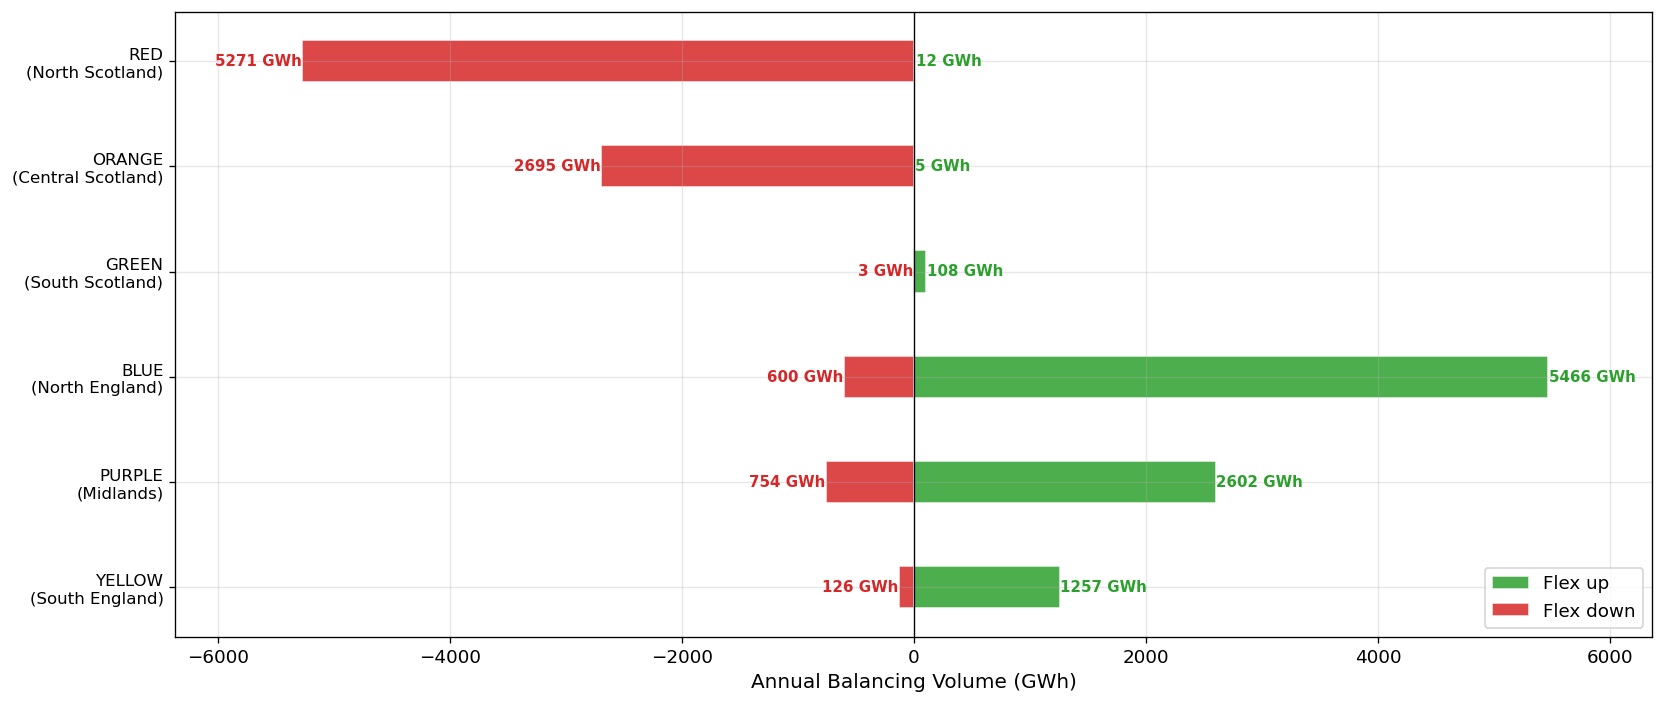


Annual Flexibility Volumes by Zone (GWh):
        Flex Up Flex Down Total Change Net
zone 
red 12.5 -5270.8 -5258.3 -5258.3
orange 4.8 -2695.1 -2690.2 -2690.2
green 107.8 -3.5 104.3 104.3
blue 5465.8 -599.8 4866.0 4866.0
purple 2602.0 -754.1 1847.9 1847.9
yellow 1256.7 -126.3 1130.4 1130.4

Total system flex-up: 9450 GWh
Total system flex-down: 9450 GWh


In [ ]:
# "" Plot 1a: Annual flex-up & flex-down by zone (horizontal stacked bar) """""

# Aggregate across all days for each zone
zone_annual = zone_daily[zone_daily['zone'].isin(ZONE_ORDER)].groupby('zone').agg(
    flex_up_gwh=('flex_up_mwh', lambda x: x.sum() / 1e3),
    flex_down_gwh=('flex_down_mwh', lambda x: x.sum() / 1e3),
    total_change_gwh=('total_change_mwh', lambda x: x.sum() / 1e3),
).reindex(ZONE_ORDER)

fig, ax = plt.subplots(figsize=(14, 6))
y_pos = np.arange(len(ZONE_ORDER))
zone_labels = [f"{z.upper()}\n({ZONE_NAMES[z]})" for z in ZONE_ORDER]

# Flex-up bars (positive, green)
bars_up = ax.barh(y_pos, zone_annual['flex_up_gwh'], height=0.4,
                  color='#2ca02c', alpha=0.85, label='Flex up', edgecolor='white')

# Flex-down bars (negative, red)
bars_down = ax.barh(y_pos, -zone_annual['flex_down_gwh'].abs(), height=0.4,
                    color='#d62728', alpha=0.85, label='Flex down', edgecolor='white')

# Add value labels
for i, (up, down) in enumerate(zip(zone_annual['flex_up_gwh'], zone_annual['flex_down_gwh'])):
    if up > 0:
        ax.text(up + 5, i, f'{up:.0f} GWh', va='center', fontsize=9, fontweight='bold', color='#2ca02c')
    if abs(down) > 0:
        ax.text(-abs(down) - 5, i, f'{abs(down):.0f} GWh', va='center', ha='right',
                fontsize=9, fontweight='bold', color='#d62728')

ax.set_yticks(y_pos)
ax.set_yticklabels(zone_labels, fontsize=10)
ax.set_xlabel('Annual Balancing Volume (GWh)', fontsize=12)
ax.set_title('',
             fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.legend(loc='lower right', fontsize=11)
# Extend x-axis range for better label spacing
max_val = max(zone_annual['flex_up_gwh'].max(), zone_annual['flex_down_gwh'].abs().max())
ax.set_xlim(-(max_val + 900), max_val + 900)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_annual_flex_by_zone.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\nAnnual Flexibility Volumes by Zone (GWh):")
summary = zone_annual.copy()
summary['net_gwh'] = summary['flex_up_gwh'] - summary['flex_down_gwh'].abs()
summary.columns = ['Flex Up', 'Flex Down', 'Total Change', 'Net']
print(summary.round(1).to_string())
print(f"\nTotal system flex-up: {zone_annual['flex_up_gwh'].sum():.0f} GWh")
print(f"Total system flex-down: {zone_annual['flex_down_gwh'].abs().sum():.0f} GWh")

## Plot 1b: Net Balancing Position - Zone Imbalance Waterfall

This waterfall chart shows the **net balance** for each zone. Zones that are net exporters (constrained, curtailed) appear in red; zones that are net importers (need more generation) appear in green. The system should approximately balance - total curtailment ~ total ramp-up.

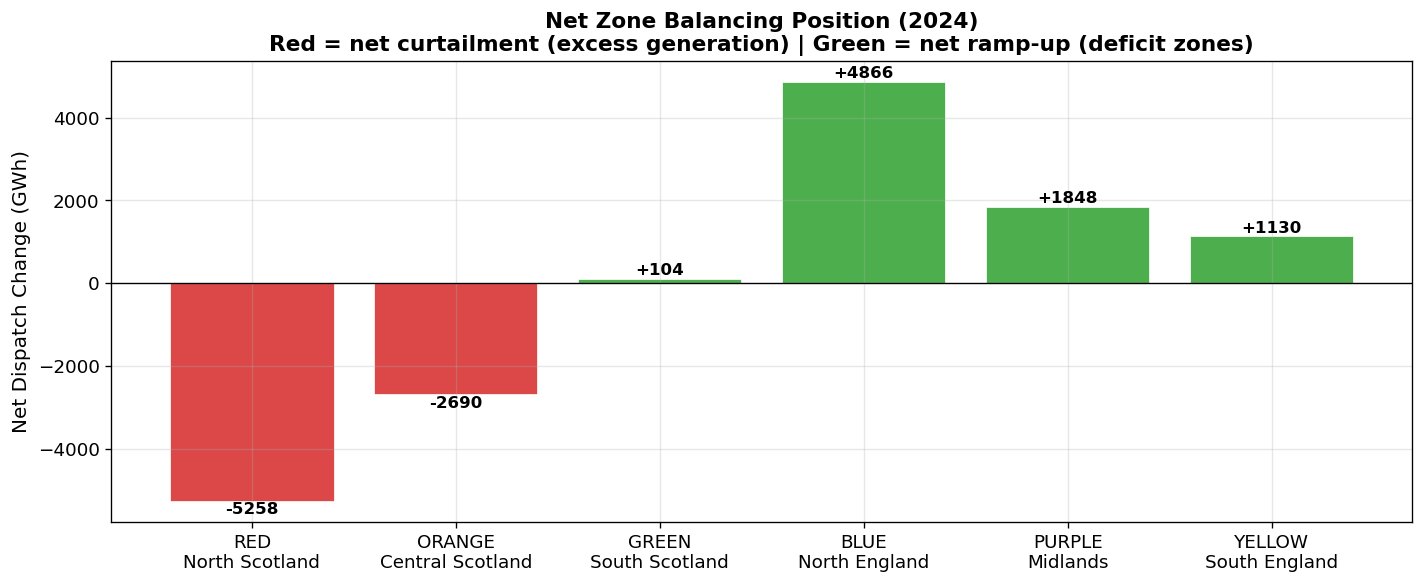

In [ ]:
# "" Plot 1b: Waterfall of net zone balancing position """"""""""""""""""""""

net = zone_annual['total_change_gwh'].reindex(ZONE_ORDER)
colors_waterfall = ['#d62728' if v < 0 else '#2ca02c' for v in net]

fig, ax = plt.subplots(figsize=(12, 5))
zone_labels_short = [f"{z.upper()}\n{ZONE_NAMES[z]}" for z in ZONE_ORDER]
bars = ax.bar(zone_labels_short, net, color=colors_waterfall, edgecolor='white', linewidth=0.5, alpha=0.85)

# Value labels
for bar, val in zip(bars, net):
    y_pos = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, y_pos + (20 if val >= 0 else -20),
            f'{val:+.0f}', ha='center', va='bottom' if val >= 0 else 'top',
            fontsize=10, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Net Dispatch Change (GWh)', fontsize=12)
ax.set_title('Net Zone Balancing Position (2024)\n'
             'Red = net curtailment (excess generation) | Green = net ramp-up (deficit zones)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_zone_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Section 2 - Seasonal Congestion Patterns

> *"Is the grid more congested in winter or summer?"*

## Plot 2a: Monthly Evolution of Zone Balancing Volumes (Heatmap)

A heatmap of **monthly flex volumes** by zone reveals seasonal patterns. We expect higher congestion (larger volumes) in winter months when wind generation is highest and flows from Scotland to England exceed constraint limits. Summer may show lower overall congestion but potentially different geographic patterns (e.g. solar-driven southern flexibility needs).

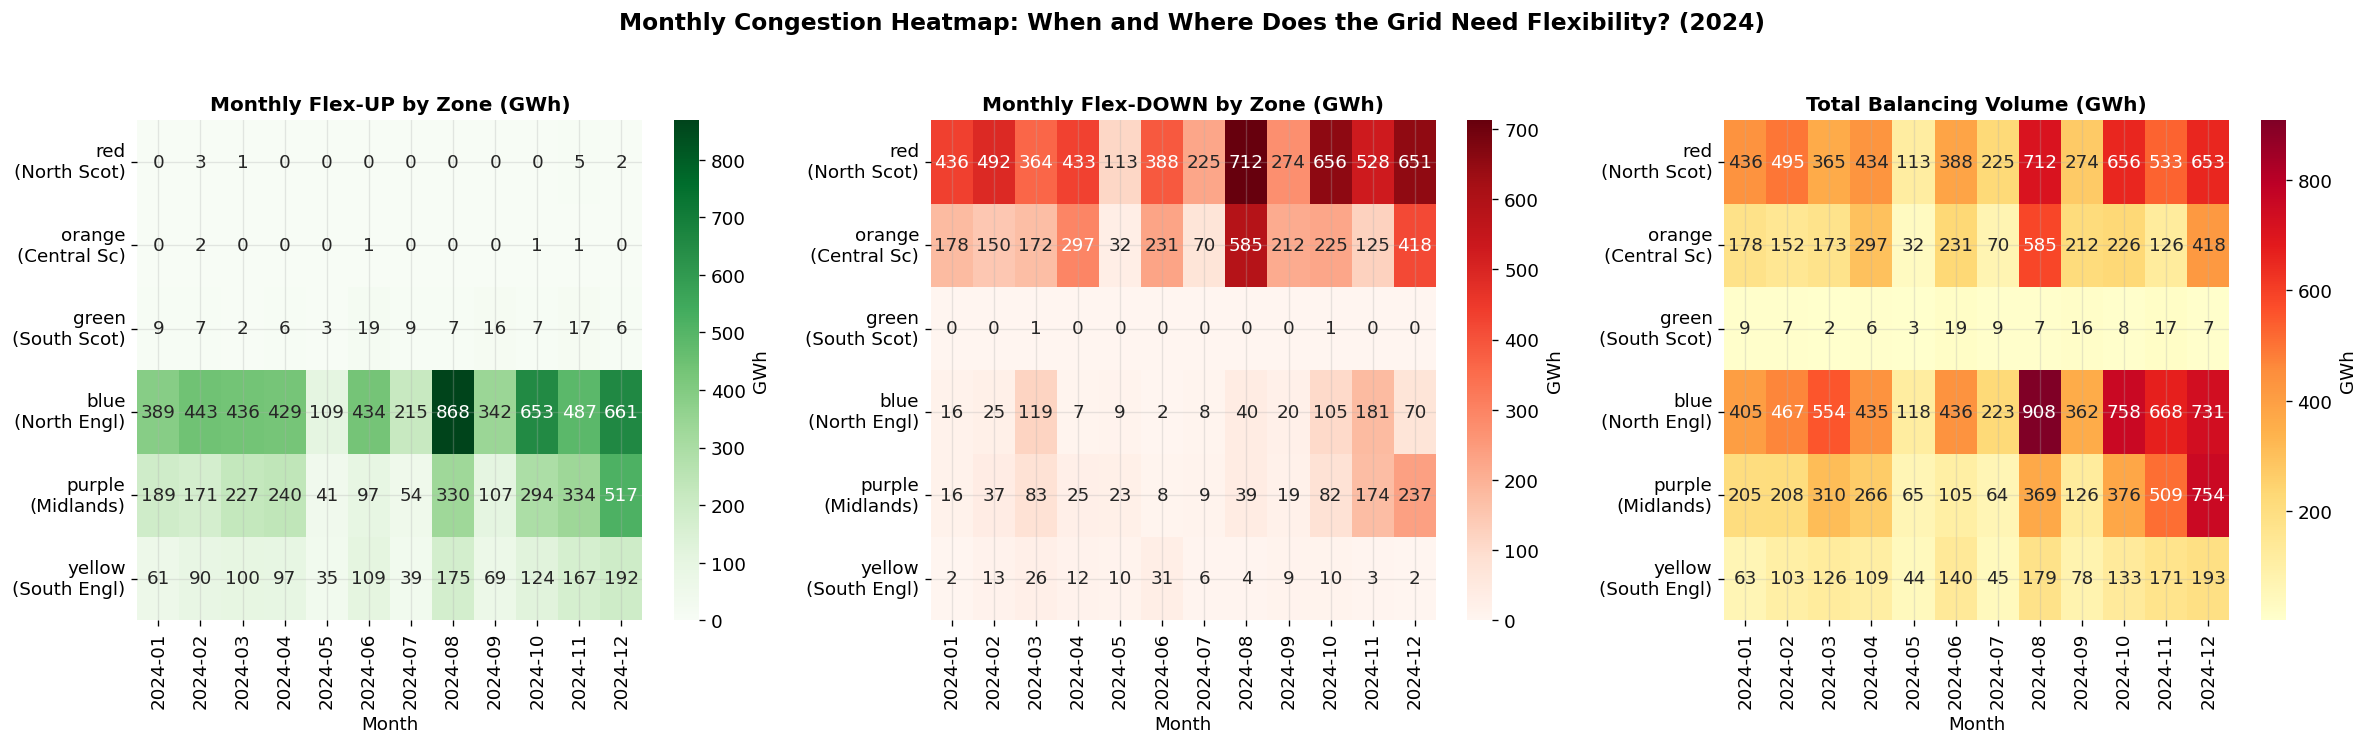


Seasonal comparison:
  Winter months (Jan-Mar, Nov-Dec): 9038 GWh total balancing
  Summer months (Jun-Aug): 4714 GWh total balancing
  Winter/Summer ratio: 1.9x


In [ ]:
# "" Plot 2a: Monthly heatmap - zone - month """""""""""""""""""""""""""""""""

# Separate flex up and down by month and zone
zone_monthly = zone_daily[zone_daily['zone'].isin(ZONE_ORDER)].copy()
zone_monthly['flex_down_abs'] = zone_monthly['flex_down_mwh'].abs()

monthly_up = zone_monthly.groupby(['month', 'zone'])['flex_up_mwh'].sum().unstack(fill_value=0) / 1e3
monthly_down = zone_monthly.groupby(['month', 'zone'])['flex_down_abs'].sum().unstack(fill_value=0) / 1e3

# Reorder columns north -> south
monthly_up = monthly_up.reindex(columns=ZONE_ORDER, fill_value=0)
monthly_down = monthly_down.reindex(columns=ZONE_ORDER, fill_value=0)

# Combined total volume (absolute)
monthly_total = monthly_up + monthly_down

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

month_labels = [str(m) for m in monthly_total.index]
zone_labels = [f"{z}\n({ZONE_NAMES[z][:10]})" for z in ZONE_ORDER]

# Flex-up heatmap
sns.heatmap(monthly_up.T.values, ax=axes[0], cmap='Greens', annot=True, fmt='.0f',
            xticklabels=month_labels, yticklabels=zone_labels, cbar_kws={'label': 'GWh'})
axes[0].set_title('Monthly Flex-UP by Zone (GWh)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month')

# Flex-down heatmap
sns.heatmap(monthly_down.T.values, ax=axes[1], cmap='Reds', annot=True, fmt='.0f',
            xticklabels=month_labels, yticklabels=zone_labels, cbar_kws={'label': 'GWh'})
axes[1].set_title('Monthly Flex-DOWN by Zone (GWh)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Month')

# Total volume heatmap
sns.heatmap(monthly_total.T.values, ax=axes[2], cmap='YlOrRd', annot=True, fmt='.0f',
            xticklabels=month_labels, yticklabels=zone_labels, cbar_kws={'label': 'GWh'})
axes[2].set_title('Total Balancing Volume (GWh)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Month')

fig.suptitle('Monthly Congestion Heatmap: When and Where Does the Grid Need Flexibility? (2024)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_monthly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print seasonal summary
winter_months = ['2024-01', '2024-02', '2024-03', '2024-11', '2024-12']
summer_months = ['2024-06', '2024-07', '2024-08']
monthly_total_sum = monthly_total.sum(axis=1)
winter_vol = monthly_total_sum[[m for m in monthly_total_sum.index if str(m) in winter_months]].sum()
summer_vol = monthly_total_sum[[m for m in monthly_total_sum.index if str(m) in summer_months]].sum()
print(f"\nSeasonal comparison:")
print(f" Winter months (Jan-Mar, Nov-Dec): {winter_vol:.0f} GWh total balancing")
print(f" Summer months (Jun-Aug): {summer_vol:.0f} GWh total balancing")
print(f" Winter/Summer ratio: {winter_vol/summer_vol:.1f}x")

## Plot 2b: Monthly Total System Balancing Volume - Stacked Area by Zone

An area chart showing how the **total monthly balancing burden** distributes across zones, making the seasonal pattern and zone contributions immediately visible. This complements the heatmap with a more intuitive time-series view.

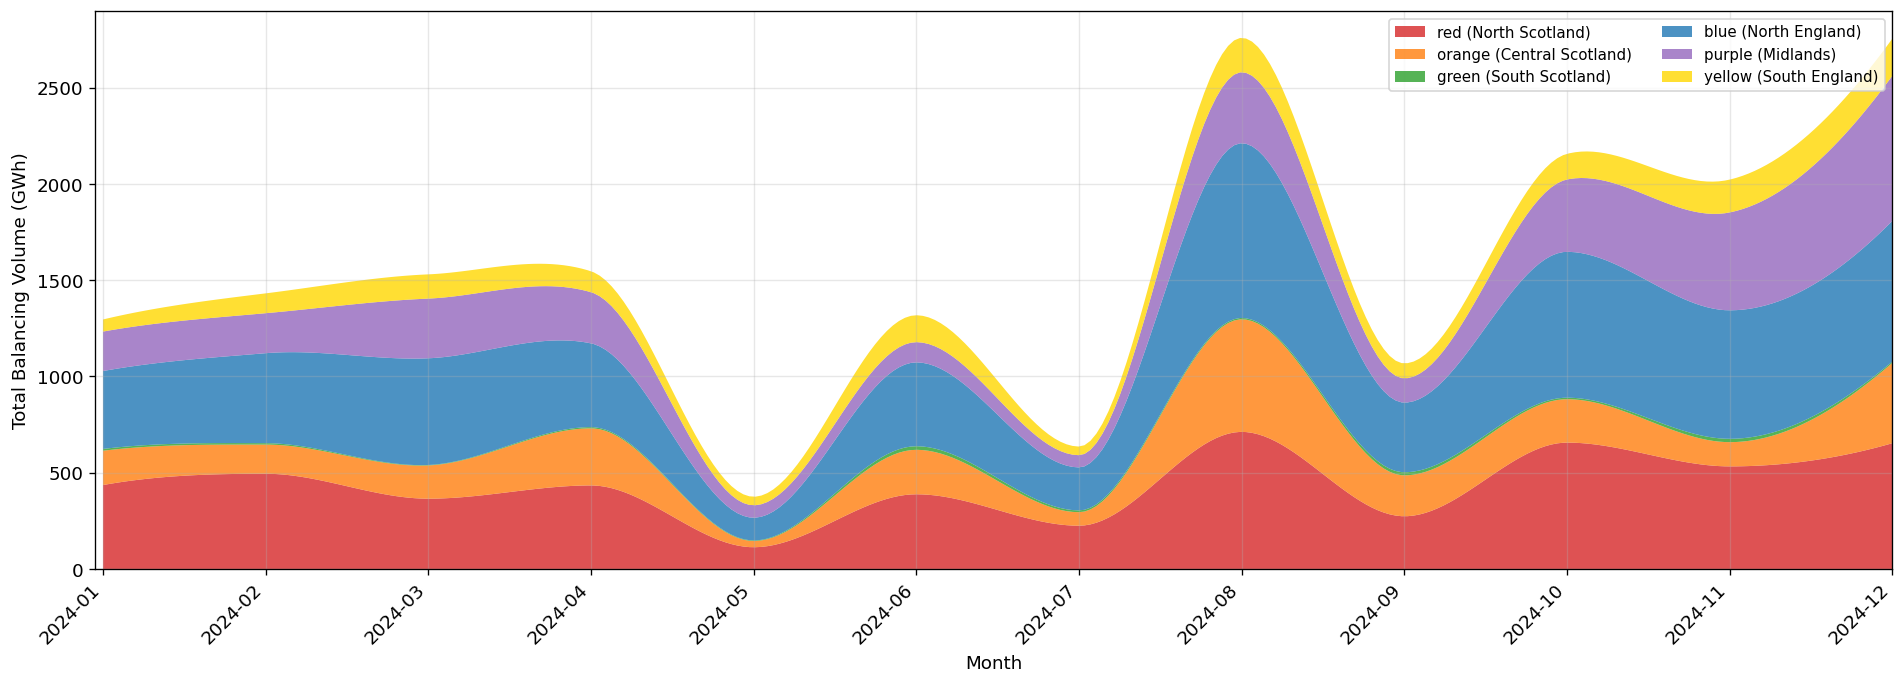

In [ ]:
from scipy.interpolate import PchipInterpolator

# Combine flex-up and flex-down into total balancing volume (absolute terms)
monthly_combined = monthly_up + monthly_down

fig, ax = plt.subplots(figsize=(16, 6))

# Original x positions (month midpoints)
x_orig = np.arange(len(monthly_combined))
# Fine grid for smooth curves (100 points between first and last month)
x_fine = np.linspace(x_orig[0], x_orig[-1], 300)

# Interpolate each zone's data with monotone PCHIP spline (preserves positivity better)
smooth_data = []
for z in ZONE_ORDER:
    y_orig = monthly_combined[z].values.astype(float)
    interp = PchipInterpolator(x_orig, y_orig)
    y_fine = np.clip(interp(x_fine), 0, None) # ensure non-negative
    smooth_data.append(y_fine)

ax.stackplot(x_fine, *smooth_data,
             labels=[f"{z} ({ZONE_NAMES[z]})" for z in ZONE_ORDER],
             colors=[ZONE_COLORS[z] for z in ZONE_ORDER], alpha=0.8)
ax.set_ylabel('Total Balancing Volume (GWh)', fontsize=11)
ax.set_title('',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.set_xlim(0, 0)

# Shared x-axis - show month labels at the original positions
ax.set_xticks(x_orig)
ax.set_xticklabels([str(m) for m in monthly_combined.index], rotation=45, ha='right')
ax.set_xlabel('Month', fontsize=11)

fig.suptitle('',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_monthly_area.png', dpi=150, bbox_inches='tight')
plt.show()


## Plot 2c: Daily Balancing Volume Time Series with Rolling Average

A daily time series showing the **total daily flex volume** (up + |down|) across all zones, with a 7-day rolling average overlay. This reveals short-term variability as well as seasonal trends - e.g., windy weeks causing spikes in winter.

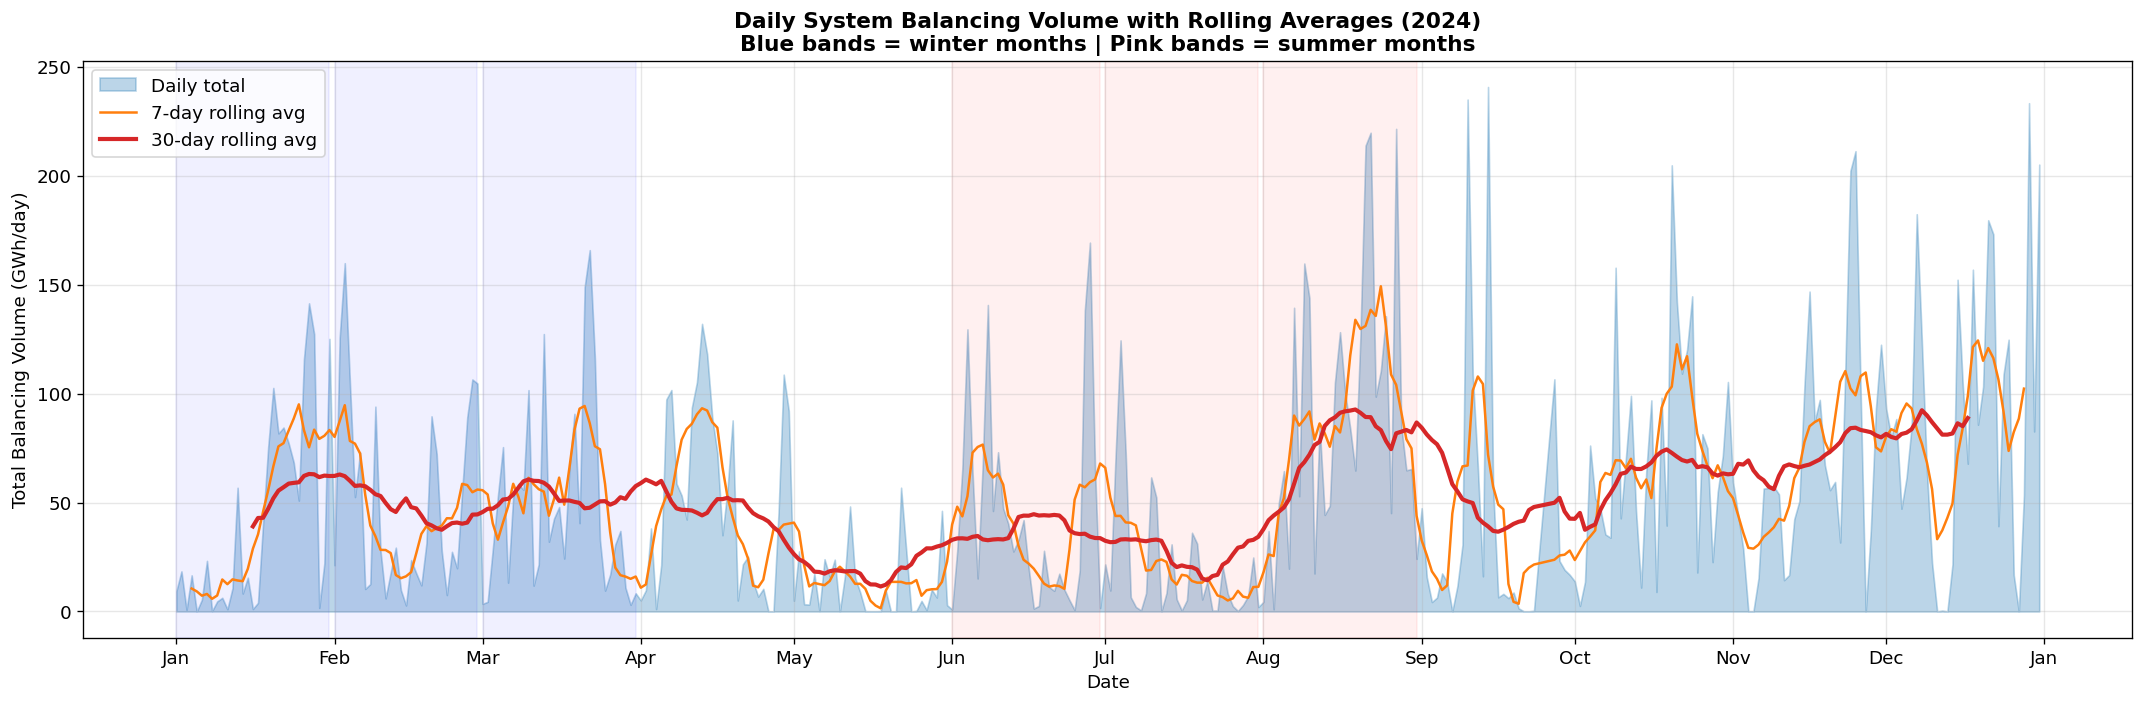

Busiest day: 2024-09-14 - 240.7 GWh
Quietest day: 2024-01-05 - 0.0 GWh
Mean daily: 52.1 GWh/day
Std dev: 52.6 GWh/day


In [ ]:

daily_total = zone_daily[zone_daily['zone'].isin(ZONE_ORDER)].groupby('date').agg(
    flex_up=('flex_up_mwh', 'sum'),
    flex_down=('flex_down_mwh', lambda x: x.abs().sum()),
).sort_index()
daily_total['total'] = daily_total['flex_up'] + daily_total['flex_down']
daily_total['total_gwh'] = daily_total['total'] / 1e3
daily_total['rolling_7d'] = daily_total['total_gwh'].rolling(7, center=True).mean()
daily_total['rolling_30d'] = daily_total['total_gwh'].rolling(30, center=True).mean()

fig, ax = plt.subplots(figsize=(18, 6))
ax.fill_between(daily_total.index, daily_total['total_gwh'], alpha=0.3, color='#1f77b4', label='Daily total')
ax.plot(daily_total.index, daily_total['rolling_7d'], color='#ff7f0e', linewidth=1.5, label='7-day rolling avg')
ax.plot(daily_total.index, daily_total['rolling_30d'], color='#d62728', linewidth=2.5, label='30-day rolling avg')

# Highlight winter/summer bands
for yr_month in ['2024-01', '2024-02', '2024-03']:
    start = pd.Timestamp(f'{yr_month}-01')
    end = start + pd.offsets.MonthEnd(0)
    ax.axvspan(start, end, alpha=0.06, color='blue')
for yr_month in ['2024-06', '2024-07', '2024-08']:
    start = pd.Timestamp(f'{yr_month}-01')
    end = start + pd.offsets.MonthEnd(0)
    ax.axvspan(start, end, alpha=0.06, color='red')

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Total Balancing Volume (GWh/day)', fontsize=11)
ax.set_title('Daily System Balancing Volume with Rolling Averages (2024)\n'
             'Blue bands = winter months | Pink bands = summer months',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_daily_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

# Busiest and quietest days
print(f"Busiest day: {daily_total['total_gwh'].idxmax().strftime('%Y-%m-%d')} " {daily_total['total_gwh'].max():.1f} GWh")
print(f"Quietest day: {daily_total['total_gwh'].idxmin().strftime('%Y-%m-%d')} " {daily_total['total_gwh'].min():.1f} GWh")
print(f"Mean daily: {daily_total['total_gwh'].mean():.1f} GWh/day")
print(f"Std dev: {daily_total['total_gwh'].std():.1f} GWh/day")

## Plot 2d: Intraday Congestion Profile - Average Flex by Hour of Day

When during the day is the grid most congested? This plot shows the **average half-hourly flex volume by hour**, split by zone, revealing whether congestion peaks at night (low demand + high wind), morning ramp, or afternoon solar shoulder.

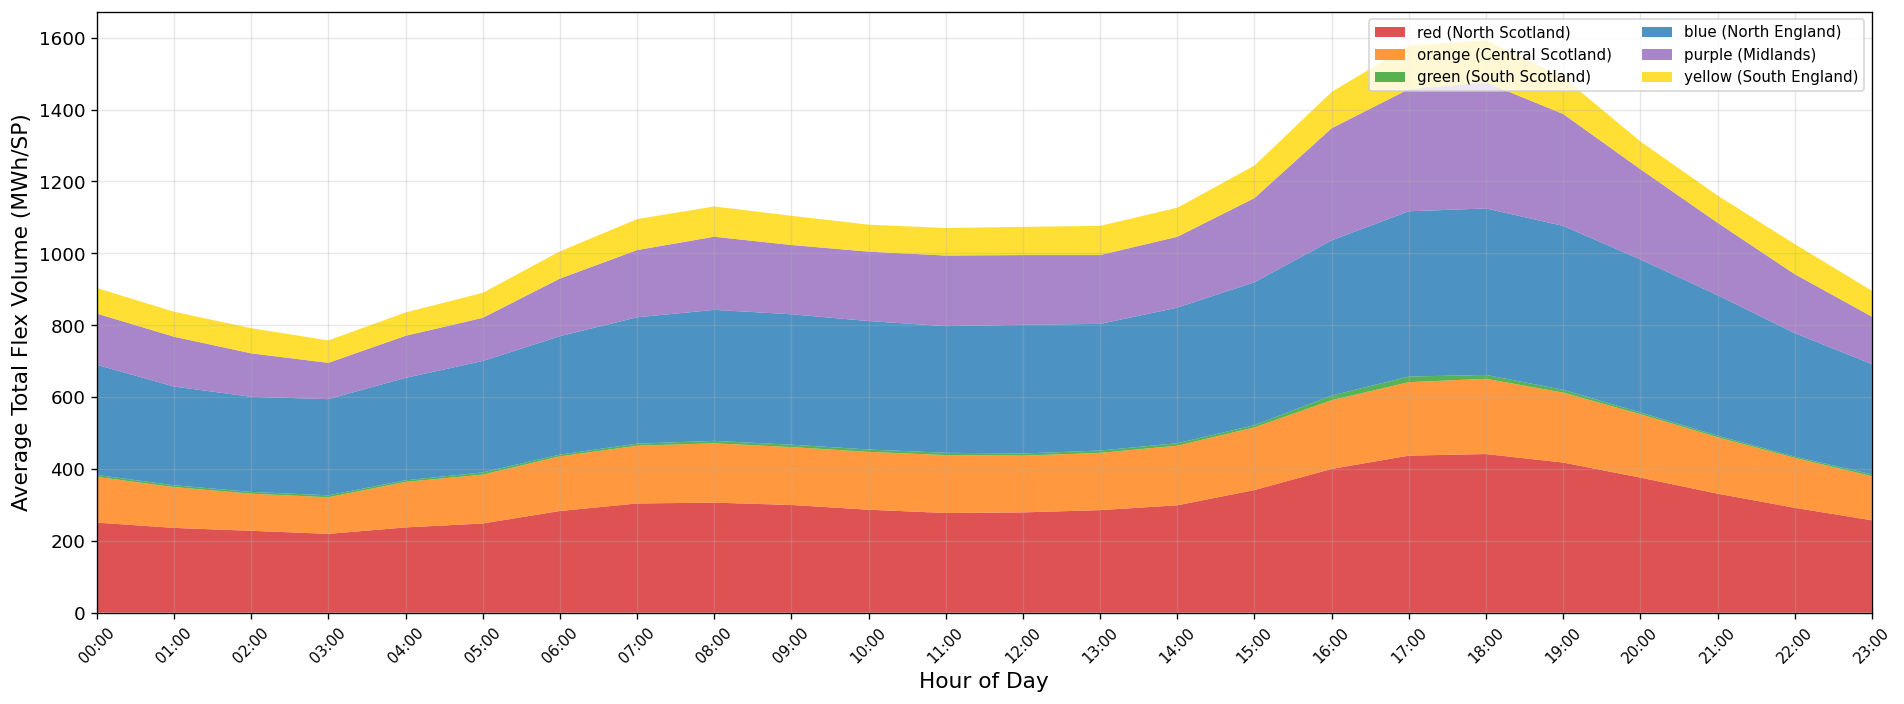

In [ ]:

zone_sp_clean = zone_sp[zone_sp['zone'].isin(ZONE_ORDER)].copy()
zone_sp_clean['total_flex'] = zone_sp_clean['flex_up_mwh'] + zone_sp_clean['flex_down_mwh'].abs()

hourly_profile = zone_sp_clean.groupby(['hour', 'zone'])['total_flex'].mean().unstack(fill_value=0)
hourly_profile = hourly_profile.reindex(columns=ZONE_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(16, 6))
ax.stackplot(hourly_profile.index, *[hourly_profile[z].values for z in ZONE_ORDER],
             labels=[f"{z} ({ZONE_NAMES[z]})" for z in ZONE_ORDER],
             colors=[ZONE_COLORS[z] for z in ZONE_ORDER], alpha=0.8)

ax.set_xlabel('Hour of Day', fontsize=13)
ax.set_ylabel('Average Total Flex Volume (MWh/SP)', fontsize=13)
ax.set_title('',
             fontsize=13, fontweight='bold')
ax.set_xlim(-0, 23)
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, fontsize=9)
ax.legend(loc='upper right', fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_intraday_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 2e: Winter vs Summer Congestion Comparison - Side-by-Side Zone Profiles

A direct side-by-side comparison of flex-up and flex-down volumes in **winter** (Jan-Mar + Nov-Dec) vs **summer** (Jun-Aug) for each zone. This answers the key question: *How much worse is winter congestion, and which zones are most affected?*

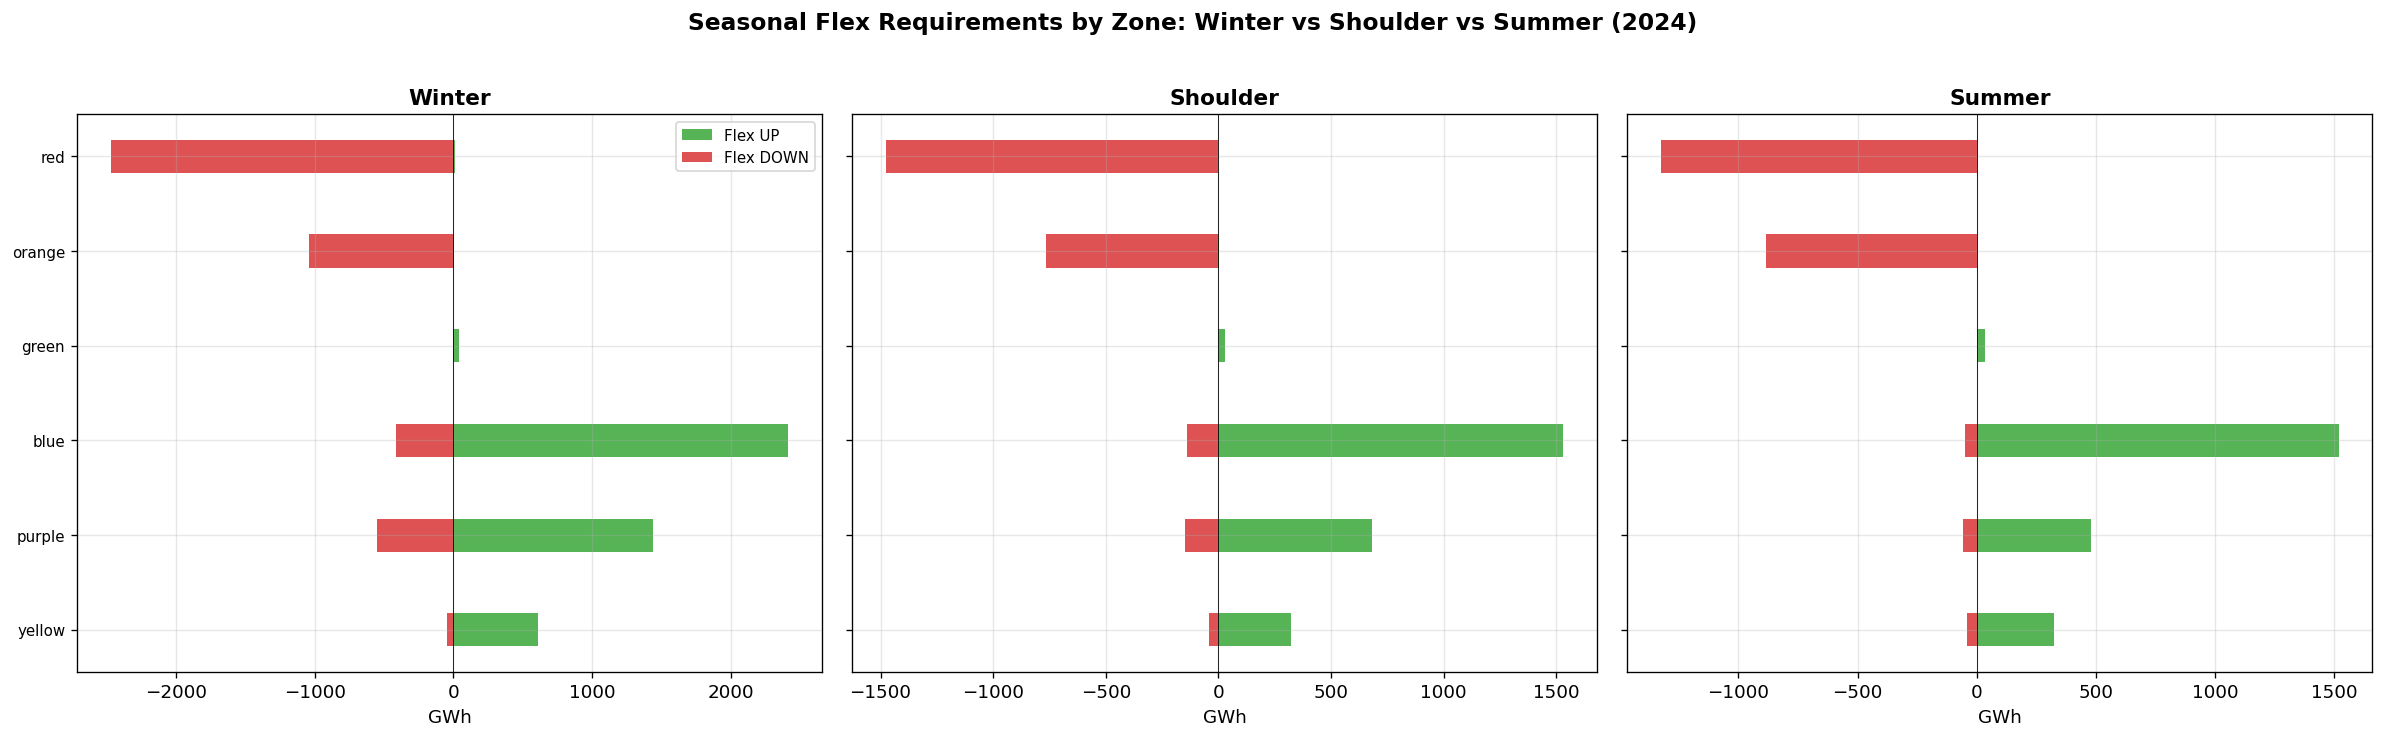

  red (North Scotland ): Winter/Summer = 1.9x
  orange (Central Scotland): Winter/Summer = 1.2x
  green (South Scotland ): Winter/Summer = 1.2x
  blue (North England ): Winter/Summer = 1.8x
  purple (Midlands ): Winter/Summer = 3.7x
  yellow (South England ): Winter/Summer = 1.8x


In [ ]:
# "" Plot 2e: Winter vs Summer zone comparison """""""""""""""""""""""""""""""""

zone_daily_clean = zone_daily[zone_daily['zone'].isin(ZONE_ORDER)].copy()
zone_daily_clean['season'] = zone_daily_clean['date'].dt.month.map(
    lambda m: 'Winter' if m in [1, 2, 3, 11, 12] else ('Summer' if m in [6, 7, 8] else 'Shoulder')
)

seasonal = zone_daily_clean.groupby(['season', 'zone']).agg(
    flex_up_gwh=('flex_up_mwh', lambda x: x.sum() / 1e3),
    flex_down_gwh=('flex_down_mwh', lambda x: x.abs().sum() / 1e3),
).reset_index()
seasonal['total_gwh'] = seasonal['flex_up_gwh'] + seasonal['flex_down_gwh']

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
for ax, season in zip(axes, ['Winter', 'Shoulder', 'Summer']):
    s_data = seasonal[seasonal['season'] == season].set_index('zone').reindex(ZONE_ORDER)
    y = np.arange(len(ZONE_ORDER))
    zone_labels = [f"{z}\n({ZONE_NAMES[z]})" for z in ZONE_ORDER]
    
    # Flex up (right) and flex down (left)
    ax.barh(y, s_data['flex_up_gwh'], height=0.35, color='#2ca02c', alpha=0.8, label='Flex UP')
    ax.barh(y, -s_data['flex_down_gwh'], height=0.35, color='#d62728', alpha=0.8, label='Flex DOWN')
    
    ax.set_yticks(y)
    ax.set_yticklabels(zone_labels if ax == axes[0] else [z for z in ZONE_ORDER], fontsize=9)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title(f'{season}', fontsize=13, fontweight='bold')
    ax.set_xlabel('GWh')
    if ax == axes[0]:
        ax.legend(fontsize=9)
    ax.invert_yaxis()

fig.suptitle('Seasonal Flex Requirements by Zone: Winter vs Shoulder vs Summer (2024)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_seasonal_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print ratios
for z in ZONE_ORDER:
    w = seasonal[(seasonal['season']=='Winter') & (seasonal['zone']==z)]['total_gwh'].values
    s = seasonal[(seasonal['season']=='Summer') & (seasonal['zone']==z)]['total_gwh'].values
    if len(w) > 0 and len(s) > 0 and s[0] > 0:
        print(f" {z:8s} ({ZONE_NAMES[z]:16s}): Winter/Summer = {w[0]/s[0]:.1f}x")

---
# Section 3 - Geographic Choropleth Map

## Plot 3: Annual Balancing Volumes on GB Map

A geographic choropleth showing the total annual flex-up (green) and flex-down (red) volumes for each zone, overlaid on the GB outline with transmission constraint boundaries. This extends the `IV_plot_balancing_volumes.ipynb` analysis from a single day to the full year. Zone intensity is proportional to volume magnitude.

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'PyPSA-Eur' has buses, carriers, generators, links, loads, storage_units


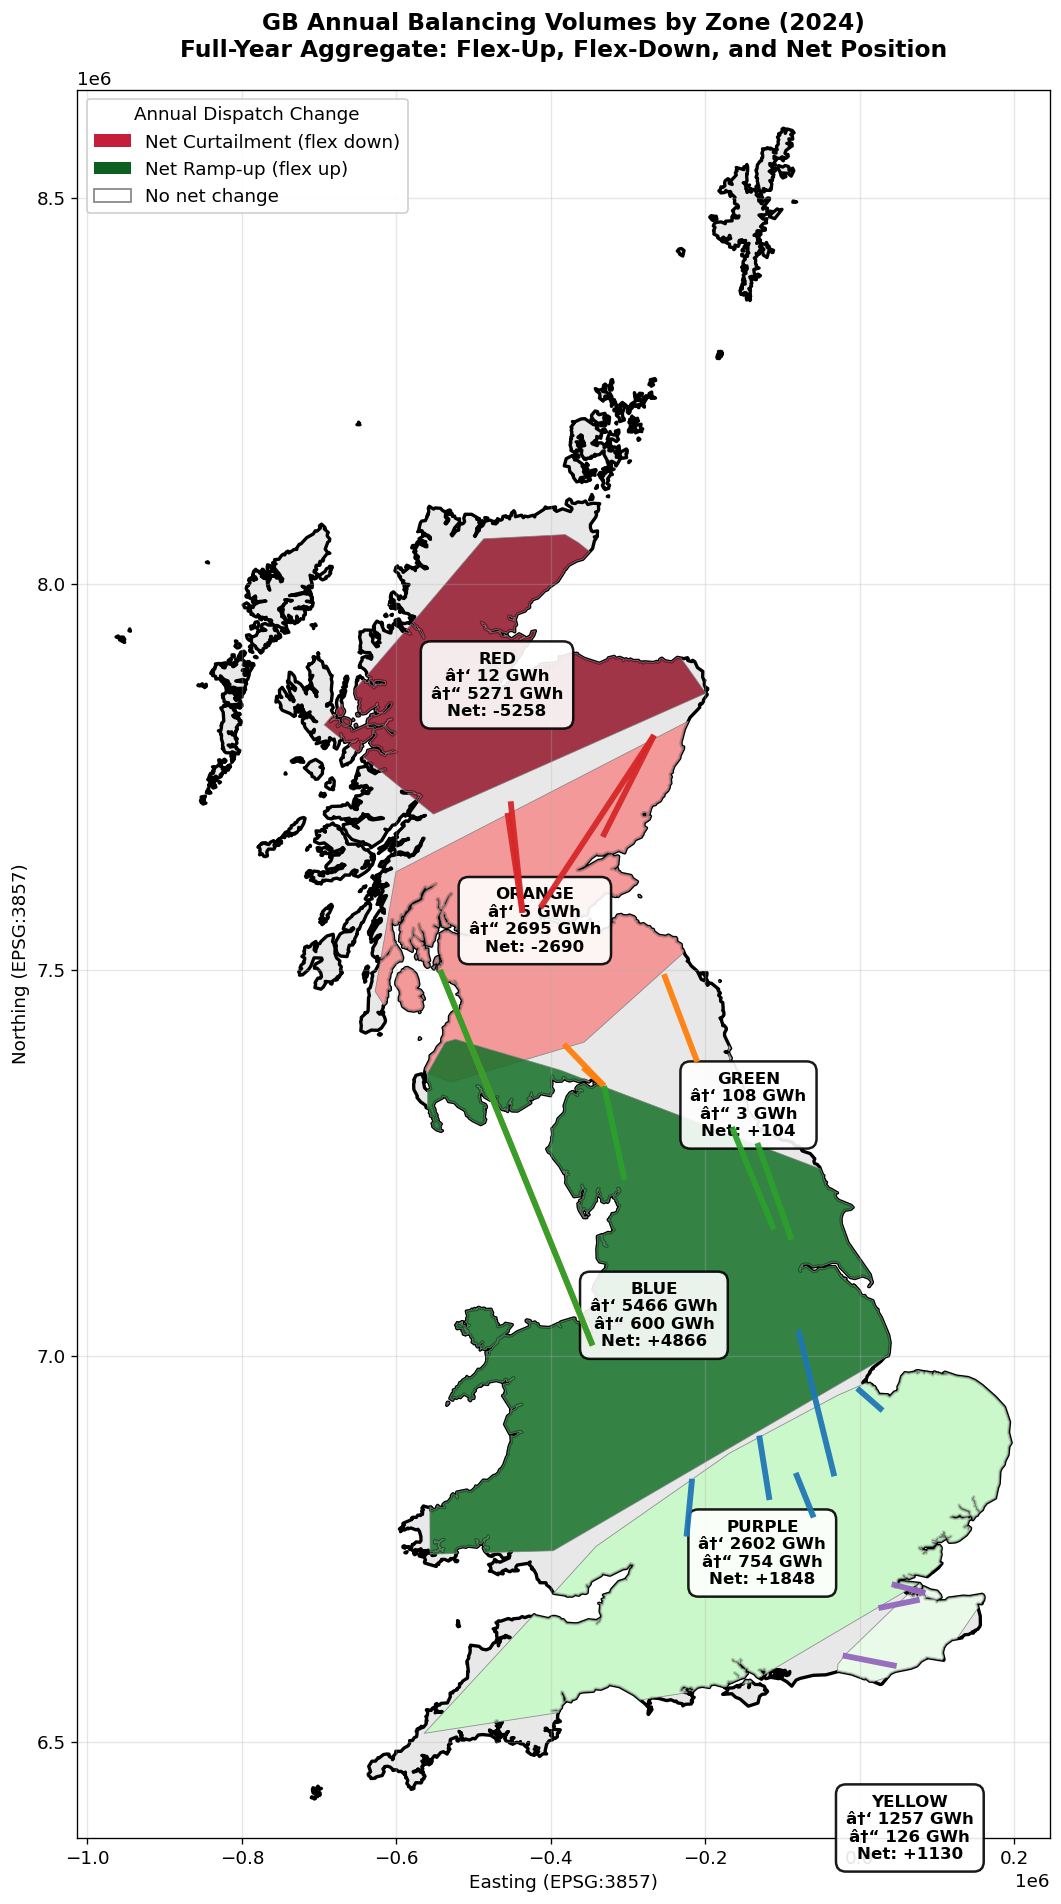

In [ ]:
# "" Plot 3: GB choropleth of annual balancing volumes """"""""""""""""""""""""

import geopandas as gpd
from shapely.geometry import MultiPoint, LineString
import yaml
import pypsa

gb_shape = gpd.read_file(ROOT / 'data' / 'gb_shape.geojson')

# Create zone polygons from BMU locations clipped to GB
def create_zone_polygon_clipped(bmu_class_df, gb_boundary, zone_name):
    """Build convex hull of BMU coords for a zone, clipped to GB boundary."""
    if zone_name == 'red':
        mask = (bmu_class_df['SSE-SP_side'] == 'north')
    elif zone_name == 'orange':
        mask = (bmu_class_df['SSE-SP_side'] == 'south') & (bmu_class_df['SCOTEX_side'] == 'north')
    elif zone_name == 'green':
        mask = (bmu_class_df['SCOTEX_side'] == 'south') & (bmu_class_df['SSHARN_side'] == 'north')
    elif zone_name == 'blue':
        mask = (bmu_class_df['SSHARN_side'] == 'south') & (bmu_class_df['FLOWSTH_side'] == 'north')
    elif zone_name == 'purple':
        mask = (bmu_class_df['FLOWSTH_side'] == 'south') & (bmu_class_df['SEIMP_side'] == 'north')
    elif zone_name == 'yellow':
        mask = (bmu_class_df['SEIMP_side'] == 'south')
    else:
        return None
    zone_bmus = bmu_class_df[mask]
    if len(zone_bmus) == 0:
        return None
    coords = zone_bmus[['lon', 'lat']].apply(pd.to_numeric, errors='coerce').dropna()
    if len(coords) < 3:
        return None
    points = MultiPoint([(lon, lat) for lon, lat in zip(coords['lon'], coords['lat'])])
    polygon = points.convex_hull
    try:
        gb_geom = gb_boundary.geometry.union_all()
    except AttributeError:
        gb_geom = gb_boundary.unary_union
    clipped = polygon.intersection(gb_geom)
    return clipped if clipped.is_valid and not clipped.is_empty else None

zone_polygons = {}
for z in ZONE_ORDER:
    poly = create_zone_polygon_clipped(bmu_class, gb_shape, z)
    if poly is not None:
        zone_polygons[z] = poly

# Prepare annual data 
zone_annual_map = zone_daily[zone_daily['zone'].isin(ZONE_ORDER)].groupby('zone').agg(
    flex_up=('flex_up_mwh', 'sum'),
    flex_down=('flex_down_mwh', lambda x: x.abs().sum()),
    net_change=('total_change_mwh', 'sum'),
)

# Colormaps
red_cmap = LinearSegmentedColormap.from_list('red_int', ['#ffffff', '#fee5e5', '#f68989', '#c41e3a', '#8b1428'])
green_cmap = LinearSegmentedColormap.from_list('green_int', ['#ffffff', '#e5fee5', '#89f689', '#1e8b34', '#0d5f1f'])

fig, ax = plt.subplots(figsize=(14, 16))

gb_proj = gb_shape.to_crs('EPSG:3857')
gb_proj.plot(ax=ax, facecolor='#e8e8e8', edgecolor='black', linewidth=2, zorder=0)
minx, miny, maxx, maxy = gb_proj.total_bounds
ax.set_xlim(minx - 50000, maxx + 50000)
ax.set_ylim(miny - 50000, maxy + 50000)

max_mag = max(zone_annual_map['flex_up'].max(), zone_annual_map['flex_down'].max())

for z in ZONE_ORDER:
    if z not in zone_polygons or z not in zone_annual_map.index:
        continue
    net = zone_annual_map.loc[z, 'net_change']
    polygon = zone_polygons[z]
    gdf = gpd.GeoDataFrame(geometry=[polygon], crs='EPSG:4326').to_crs('EPSG:3857')
    
    if net > 0:
        intensity = min(abs(net) / max_mag, 1.0)
        color = green_cmap(intensity)
    elif net < 0:
        intensity = min(abs(net) / max_mag, 1.0)
        color = red_cmap(intensity)
    else:
        color = '#ffffff'
    
    gdf.plot(ax=ax, facecolor=color, edgecolor='gray', linewidth=0.5, zorder=1, alpha=0.85)
    
    centroid = polygon.centroid
    if centroid.is_valid:
        c_gdf = gpd.GeoDataFrame(geometry=[centroid], crs='EPSG:4326').to_crs('EPSG:3857')
        cx, cy = c_gdf.geometry[0].x, c_gdf.geometry[0].y
        if z == 'yellow':
            cy -= 250000
        
        up_gwh = zone_annual_map.loc[z, 'flex_up'] / 1e3
        down_gwh = zone_annual_map.loc[z, 'flex_down'] / 1e3
        net_gwh = net / 1e3
        
        ax.text(cx, cy,
                f"{z.upper()}\n' {up_gwh:.0f} GWh\n" {down_gwh:.0f} GWh\nNet: {net_gwh:+.0f}",
                fontsize=10, fontweight='bold', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.9,
                          edgecolor='black', linewidth=1.5))

# Load and plot constraint boundaries
try:
    with open(ROOT / 'data' / 'transmission_boundaries.yaml') as f:
        boundaries = yaml.safe_load(f)
    n_nodal = pypsa.Network(RESULTS_DIR / '2024-01-01' / 'network_flex_s_nodal.nc')
    buses_nodal = n_nodal.buses
    constraint_colors = {'SSE-SP': '#d62728', 'SCOTEX': '#ff7f0e', 'SSHARN': '#2ca02c',
                         'FLOWSTH': '#1f77b4', 'SEIMP': '#9467bd'}
    for cname, ccolor in constraint_colors.items():
        if cname not in boundaries:
            continue
        line_geoms = []
        for l in boundaries[cname]:
            try:
                if str(l) in n_nodal.lines.index:
                    line_geoms.append(LineString([
                        (buses_nodal.loc[n_nodal.lines.loc[str(l), 'bus0'], 'x'],
                         buses_nodal.loc[n_nodal.lines.loc[str(l), 'bus0'], 'y']),
                        (buses_nodal.loc[n_nodal.lines.loc[str(l), 'bus1'], 'x'],
                         buses_nodal.loc[n_nodal.lines.loc[str(l), 'bus1'], 'y'])]))
                elif str(l) in n_nodal.links.index:
                    line_geoms.append(LineString([
                        (buses_nodal.loc[n_nodal.links.loc[str(l), 'bus0'], 'x'],
                         buses_nodal.loc[n_nodal.links.loc[str(l), 'bus0'], 'y']),
                        (buses_nodal.loc[n_nodal.links.loc[str(l), 'bus1'], 'x'],
                         buses_nodal.loc[n_nodal.links.loc[str(l), 'bus1'], 'y'])]))
            except (KeyError, ValueError):
                pass
        if line_geoms:
            gpd.GeoDataFrame(geometry=line_geoms, crs='EPSG:4326').to_crs('EPSG:3857').plot(
                ax=ax, edgecolor=ccolor, linewidth=3.5, zorder=3, alpha=0.95)
except Exception as e:
    print(f"Note: Could not overlay constraint boundaries: {e}")

# Legend
legend_els = [
    mpatches.Patch(facecolor='#c41e3a', label='Net Curtailment (flex down)'),
    mpatches.Patch(facecolor='#0d5f1f', label='Net Ramp-up (flex up)'),
    mpatches.Patch(facecolor='#ffffff', edgecolor='gray', label='No net change'),
]
ax.legend(handles=legend_els, loc='upper left', fontsize=11, framealpha=0.95,
          title='Annual Dispatch Change', title_fontsize=11)

ax.set_title('GB Annual Balancing Volumes by Zone (2024)\n'
             'Full-Year Aggregate: Flex-Up, Flex-Down, and Net Position',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Easting (EPSG:3857)')
ax.set_ylabel('Northing (EPSG:3857)')
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_gb_choropleth_annual.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Section 4 - Wind Generation vs Northern Curtailment

## Plot 4a: Correlation Between Wind Output and Northern Curtailment

The hypothesis: *When wind generation in northern zones (red/orange) is high, curtailment in those zones increases because transmission constraints prevent power from flowing south.* This scatter plot tests that by comparing daily wind dispatch against daily flex-down volume in the northern zones.

Loading zone - type data: 100%|| 366/366 [00:01<00:00, 244.66it/s]


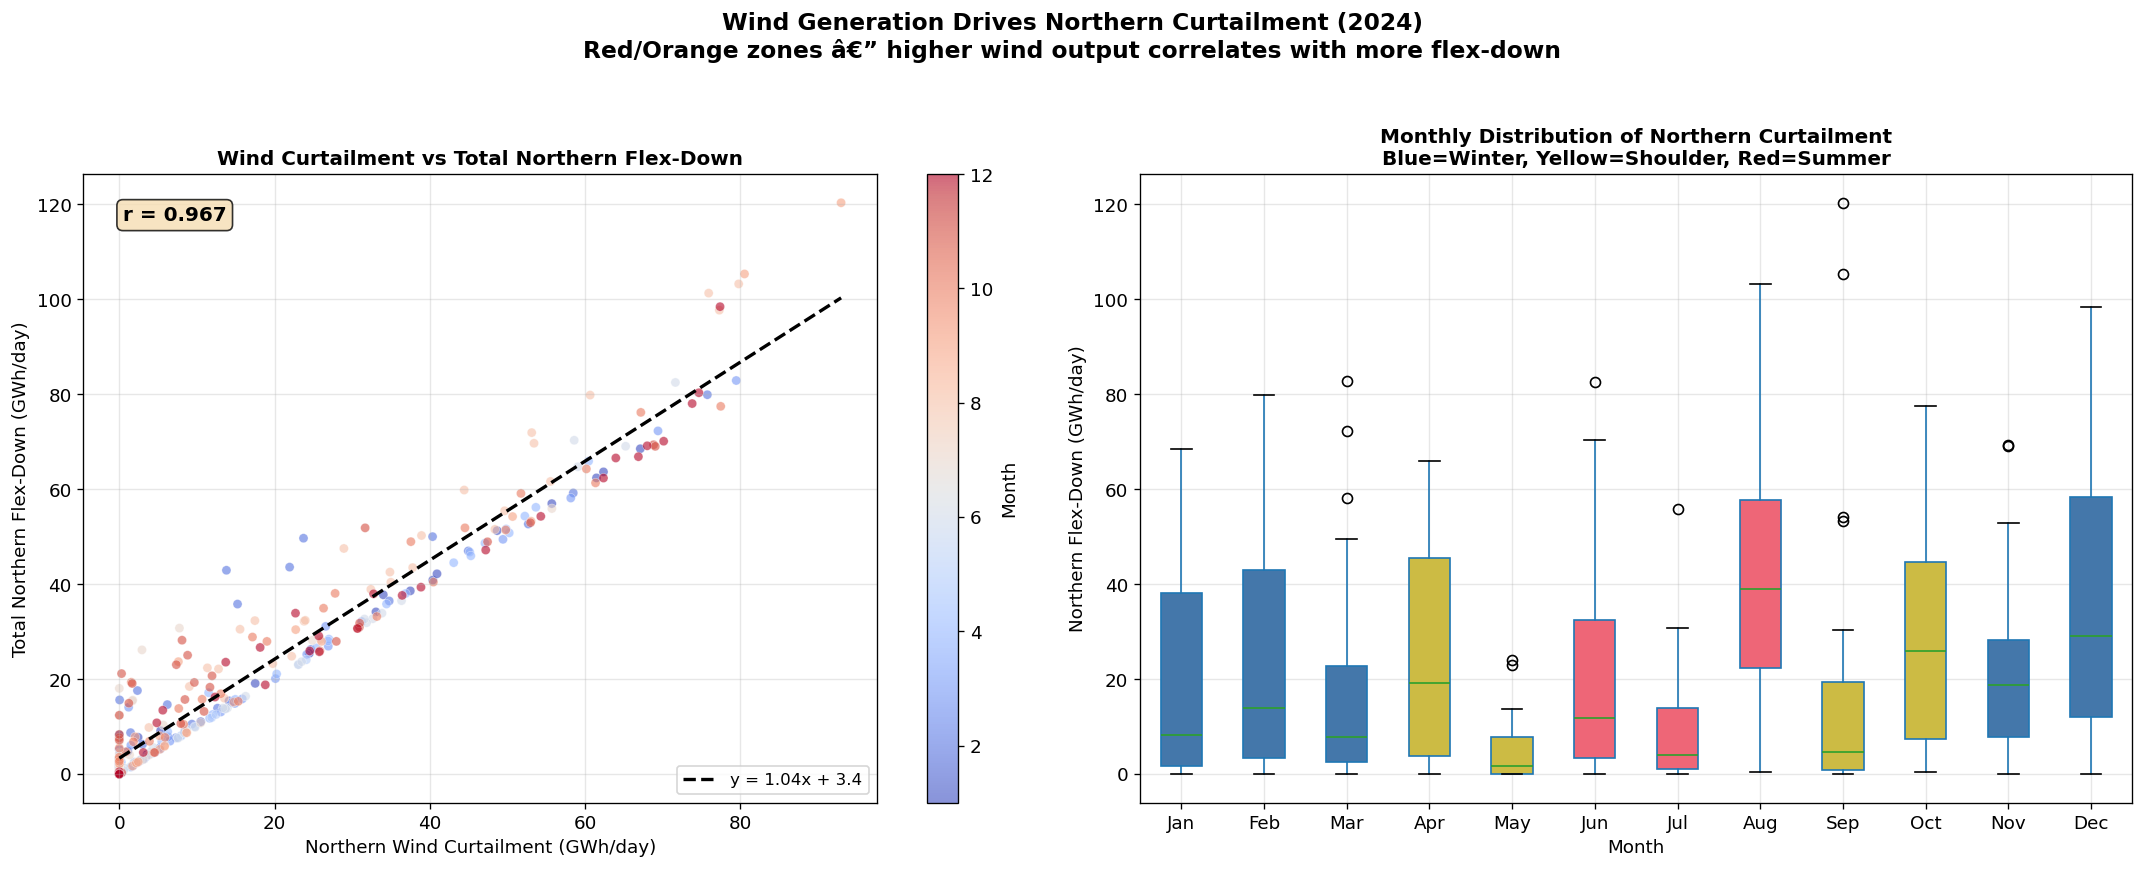

In [ ]:
# "" Plot 4a: Wind output vs northern curtailment """""""""""""""""""""""""""""

# Load zone - type dispatch data to get wind contribution per zone per day
zone_type_list = []
for day_str in tqdm(all_dates, desc="Loading zone - type data"):
    fpath = RESULTS_DIR / day_str / 'IV_dispatch_changes_by_zone_and_type_flex.csv'
    if not fpath.exists():
        continue
    df = pd.read_csv(fpath)
    df['date'] = day_str
    zone_type_list.append(df)

zone_type = pd.concat(zone_type_list, ignore_index=True)
zone_type['date'] = pd.to_datetime(zone_type['date'])

# Wind curtailment in northern zones (red, orange) - wind is onwind + offwind
north_zones = ['red', 'orange']
wind_types = ['onwind', 'offwind']

# For each day, get wind dispatch change in northern zones (negative = curtailed)
north_wind_curt = zone_type[
    (zone_type['zone'].isin(north_zones)) & (zone_type['type'].isin(wind_types))
].groupby('date')['dispatch_change_mwh'].sum().abs() / 1e3 # GWh, absolute curtailment

# Total northern flex-down per day (from zone_daily)
north_flex_down = zone_daily[
    zone_daily['zone'].isin(north_zones)
].groupby('date')['flex_down_mwh'].sum().abs() / 1e3 # GWh

# Merge
scatter_data = pd.DataFrame({
    'wind_curtailment_gwh': north_wind_curt,
    'total_flex_down_gwh': north_flex_down,
}).dropna()

# Add month for coloring
scatter_data['month'] = scatter_data.index.month

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: scatter with regression
ax = axes[0]
colors_scatter = plt.cm.coolwarm(Normalize(1, 12)(scatter_data['month']))
sc = ax.scatter(scatter_data['wind_curtailment_gwh'], scatter_data['total_flex_down_gwh'],
                c=scatter_data['month'], cmap='coolwarm', alpha=0.6, s=30, edgecolors='white', linewidth=0.3)

# Regression line
from numpy.polynomial.polynomial import polyfit
mask = scatter_data['wind_curtailment_gwh'] > 0
if mask.sum() > 10:
    x_fit = scatter_data.loc[mask, 'wind_curtailment_gwh']
    y_fit = scatter_data.loc[mask, 'total_flex_down_gwh']
    coeffs = np.polyfit(x_fit, y_fit, 1)
    x_line = np.linspace(x_fit.min(), x_fit.max(), 100)
    ax.plot(x_line, np.polyval(coeffs, x_line), 'k--', linewidth=2, label=f'y = {coeffs[0]:.2f}x + {coeffs[1]:.1f}')
    corr = scatter_data.loc[mask, ['wind_curtailment_gwh', 'total_flex_down_gwh']].corr().iloc[0, 1]
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=12,
            fontweight='bold', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.colorbar(sc, ax=ax, label='Month')
ax.set_xlabel('Northern Wind Curtailment (GWh/day)', fontsize=11)
ax.set_ylabel('Total Northern Flex-Down (GWh/day)', fontsize=11)
ax.set_title('Wind Curtailment vs Total Northern Flex-Down', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

# Right: monthly box plot of northern curtailment
ax = axes[1]
monthly_curt = scatter_data.copy()
monthly_curt['month_name'] = pd.to_datetime(scatter_data.index).strftime('%b')
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_curt['month_name'] = pd.Categorical(monthly_curt['month_name'], categories=month_order, ordered=True)

bp = monthly_curt.boxplot(column='total_flex_down_gwh', by='month_name', ax=ax,
                          patch_artist=True, return_type='dict')
# Color boxes by season
winter_color = '#4477AA'
summer_color = '#EE6677'
shoulder_color = '#CCBB44'
for i, patch in enumerate(bp['total_flex_down_gwh']['boxes']):
    month_name = month_order[i]
    if month_name in ['Jan', 'Feb', 'Mar', 'Nov', 'Dec']:
        patch.set_facecolor(winter_color)
    elif month_name in ['Jun', 'Jul', 'Aug']:
        patch.set_facecolor(summer_color)
    else:
        patch.set_facecolor(shoulder_color)

ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Northern Flex-Down (GWh/day)', fontsize=11)
ax.set_title('Monthly Distribution of Northern Curtailment\n'
             'Blue=Winter, Yellow=Shoulder, Red=Summer', fontsize=12, fontweight='bold')
plt.suptitle('') # Remove auto-title from boxplot

fig.suptitle('Wind Generation Drives Northern Curtailment (2024)\n'
             'Red/Orange zones - higher wind output correlates with more flex-down',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_wind_curtailment.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Section 5 - Monthly Clearing Price Evolution

## Plot 5a: Monthly Average Clearing Prices by Zone

How do the prices at which the IV algorithm clears balancing actions evolve across the year? High offer prices may indicate scarcity of flex-up providers; deeply negative bid prices indicate willingness to pay to maintain output (e.g., CfD-backed wind). We separate offers (positive prices) and bids (typically negative prices).

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

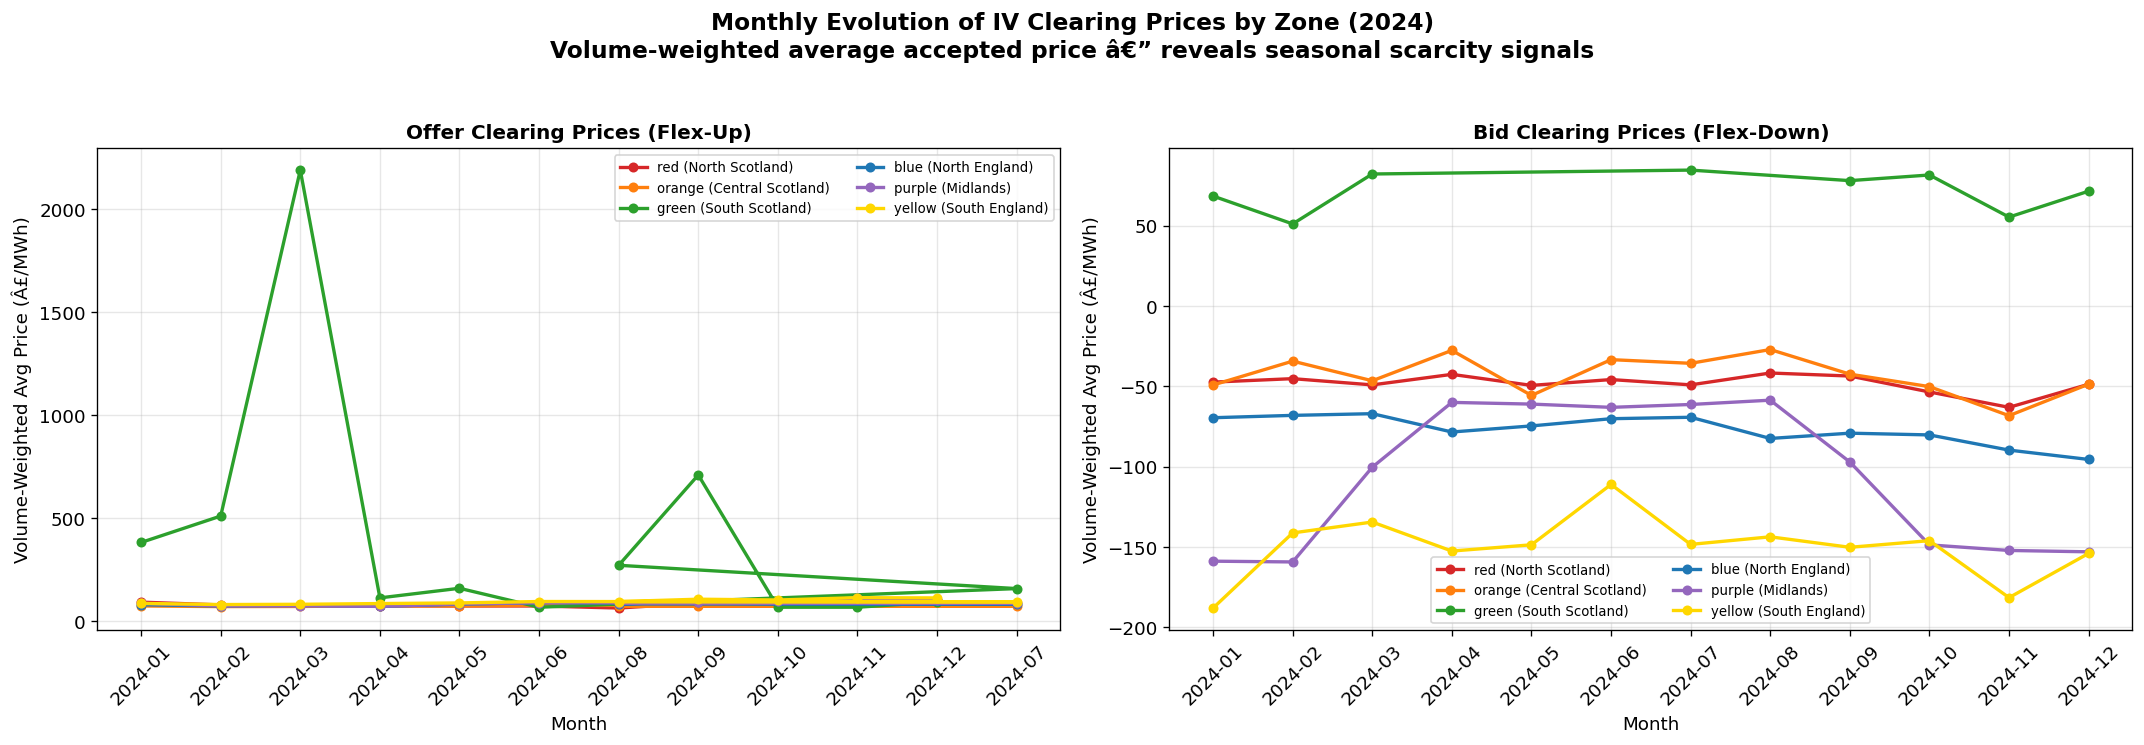

In [ ]:
# "" Plot 5a: Monthly clearing prices """""""""""""""""""""""""""""""""""""""""

# Volume-weighted average price per month per zone per action type
iv_prices = iv_actions[iv_actions['zone'].isin(ZONE_ORDER)].copy()

# Offers: volume-weighted average price
offer_prices = iv_prices[iv_prices['action_type'] == 'offer'].copy()
offer_prices['weighted_price'] = offer_prices['price_per_mwh'] * offer_prices['volume_mwh_actual']
offer_monthly = offer_prices.groupby(['month', 'zone']).agg(
    total_vol=('volume_mwh_actual', 'sum'),
    weighted_sum=('weighted_price', 'sum'),
).reset_index()
offer_monthly['avg_price'] = offer_monthly['weighted_sum'] / offer_monthly['total_vol']

# Bids: similar
bid_prices = iv_prices[iv_prices['action_type'] == 'bid'].copy()
bid_prices['weighted_price'] = bid_prices['price_per_mwh'] * bid_prices['volume_mwh_actual']
bid_monthly = bid_prices.groupby(['month', 'zone']).agg(
    total_vol=('volume_mwh_actual', 'sum'),
    weighted_sum=('weighted_price', 'sum'),
).reset_index()
bid_monthly['avg_price'] = bid_monthly['weighted_sum'] / bid_monthly['total_vol']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Offer prices
ax = axes[0]
for z in ZONE_ORDER:
    z_data = offer_monthly[offer_monthly['zone'] == z]
    if len(z_data) > 0:
        ax.plot([str(m) for m in z_data['month']], z_data['avg_price'],
                'o-', color=ZONE_COLORS[z], label=f'{z} ({ZONE_NAMES[z]})',
                linewidth=2, markersize=5)
ax.set_xlabel('Month')
ax.set_ylabel('Volume-Weighted Avg Price (GBP/MWh)')
ax.set_title('Offer Clearing Prices (Flex-Up)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.tick_params(axis='x', rotation=45)

# Bid prices
ax = axes[1]
for z in ZONE_ORDER:
    z_data = bid_monthly[bid_monthly['zone'] == z]
    if len(z_data) > 0:
        ax.plot([str(m) for m in z_data['month']], z_data['avg_price'],
                'o-', color=ZONE_COLORS[z], label=f'{z} ({ZONE_NAMES[z]})',
                linewidth=2, markersize=5)
ax.set_xlabel('Month')
ax.set_ylabel('Volume-Weighted Avg Price (GBP/MWh)')
ax.set_title('Bid Clearing Prices (Flex-Down)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.tick_params(axis='x', rotation=45)

fig.suptitle('Monthly Evolution of IV Clearing Prices by Zone (2024)\n'
             'Volume-weighted average accepted price - reveals seasonal scarcity signals',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_monthly_prices.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 5b: Monthly Clearing Prices by Technology

Which technologies set the marginal price? This reveals whether gas (expensive flex-up) or wind (negative flex-down via CfD) dominates the clearing price structure at different times of year.

---
# Section 6 - Technology Flexibility Supply: Submitted Bids & Offers

> *"How much flexibility does each technology actually offer to the market?"*

## Plot 6a: Annual Submitted Flexibility by Technology

This analyses the **submitted bids and offers** (not just accepted ones) to understand the **total flexibility supply** available from each technology. The difference between submitted and accepted reveals how much spare capacity exists - and where the bottlenecks are.

We load the raw `submitted_bids.csv` and `submitted_offers.csv` from the ELEXON API data for all 366 days, classify each BMU by carrier type using the BMU classification table, and aggregate.

In [ ]:
# Load submitted bids & offers using daily aggregation only.
# This avoids materialising the full raw tables in memory while keeping all
# downstream technology-level and monthly analyses intact.

submitted_bid_daily_list = []
submitted_offer_daily_list = []
daily_submitted_bids_rows = []
daily_submitted_offers_rows = []
submitted_bid_bmus_all = set()
submitted_offer_bmus_all = set()
submitted_bid_bmus_by_carrier = {}
submitted_offer_bmus_by_carrier = {}
missing_sub = 0


def _update_bmu_sets(df, target_by_carrier, target_all):
    for carrier, group in df.groupby('carrier'):
        target_by_carrier.setdefault(carrier, set()).update(
            group['NationalGridBmUnit'].dropna().astype(str).unique().tolist()
        )
    target_all.update(df['NationalGridBmUnit'].dropna().astype(str).unique().tolist())


for day_str in tqdm(all_dates, desc='Loading submitted bids & offers (aggregated)'):
    bids_path = DATA_DIR / day_str / 'submitted_bids.csv'
    offers_path = DATA_DIR / day_str / 'submitted_offers.csv'

    if not bids_path.exists() or not offers_path.exists():
        missing_sub += 1
        continue

    try:
        bids = pd.read_csv(
            bids_path,
            usecols=['NationalGridBmUnit', 'Bid', 'LevelFrom'],
            dtype={'NationalGridBmUnit': 'string', 'Bid': 'float32', 'LevelFrom': 'float32'},
        )
        offers = pd.read_csv(
            offers_path,
            usecols=['NationalGridBmUnit', 'Offer', 'LevelFrom'],
            dtype={'NationalGridBmUnit': 'string', 'Offer': 'float32', 'LevelFrom': 'float32'},
        )
    except Exception:
        missing_sub += 1
        continue

    bids['carrier'] = bids['NationalGridBmUnit'].map(bmu_class['carrier']).fillna('other')
    offers['carrier'] = offers['NationalGridBmUnit'].map(bmu_class['carrier']).fillna('other')

    bids['volume_mw'] = bids['LevelFrom'].abs().astype('float32')
    offers['volume_mw'] = offers['LevelFrom'].abs().astype('float32')
    bids['volume_mwh'] = (bids['volume_mw'] * 0.5).astype('float32')
    offers['volume_mwh'] = (offers['volume_mw'] * 0.5).astype('float32')
    bids['price_x_vol'] = (bids['Bid'].fillna(0) * bids['volume_mw']).astype('float32')
    offers['price_x_vol'] = (offers['Offer'].fillna(0) * offers['volume_mw']).astype('float32')

    date_val = pd.Timestamp(day_str)
    month_val = str(date_val.to_period('M'))

    daily_submitted_bids_rows.append((date_val, len(bids)))
    daily_submitted_offers_rows.append((date_val, len(offers)))

    _update_bmu_sets(
        bids[['NationalGridBmUnit', 'carrier']],
        submitted_bid_bmus_by_carrier,
        submitted_bid_bmus_all,
    )
    _update_bmu_sets(
        offers[['NationalGridBmUnit', 'carrier']],
        submitted_offer_bmus_by_carrier,
        submitted_offer_bmus_all,
    )

    bid_day = bids.groupby('carrier', as_index=False)[['volume_mwh', 'volume_mw', 'price_x_vol']].sum()
    bid_day['date'] = date_val
    bid_day['month'] = month_val
    submitted_bid_daily_list.append(
        bid_day[['date', 'month', 'carrier', 'volume_mwh', 'volume_mw', 'price_x_vol']]
    )

    offer_day = offers.groupby('carrier', as_index=False)[['volume_mwh', 'volume_mw', 'price_x_vol']].sum()
    offer_day['date'] = date_val
    offer_day['month'] = month_val
    submitted_offer_daily_list.append(
        offer_day[['date', 'month', 'carrier', 'volume_mwh', 'volume_mw', 'price_x_vol']]
    )

month_order = [
    str(p) for p in pd.period_range(pd.Timestamp(min(all_dates)), pd.Timestamp(max(all_dates)), freq='M')
]

submitted_bid_daily_carrier = pd.concat(submitted_bid_daily_list, ignore_index=True)
submitted_offer_daily_carrier = pd.concat(submitted_offer_daily_list, ignore_index=True)

for df in (submitted_bid_daily_carrier, submitted_offer_daily_carrier):
    df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

submitted_bid_by_carrier = (
    submitted_bid_daily_carrier.groupby('carrier', observed=True)['volume_mwh'].sum().sort_values(ascending=False)
)
submitted_offer_by_carrier = (
    submitted_offer_daily_carrier.groupby('carrier', observed=True)['volume_mwh'].sum().sort_values(ascending=False)
)

submitted_bid_monthly_carrier = (
    submitted_bid_daily_carrier.groupby(['month', 'carrier'], observed=True)[['volume_mwh', 'volume_mw', 'price_x_vol']]
    .sum()
    .reset_index()
)
submitted_offer_monthly_carrier = (
    submitted_offer_daily_carrier.groupby(['month', 'carrier'], observed=True)[['volume_mwh', 'volume_mw', 'price_x_vol']]
    .sum()
    .reset_index()
)

submitted_bid_stats = submitted_bid_daily_carrier.groupby('carrier', observed=True)[['volume_mwh', 'volume_mw', 'price_x_vol']].sum()
submitted_offer_stats = submitted_offer_daily_carrier.groupby('carrier', observed=True)[['volume_mwh', 'volume_mw', 'price_x_vol']].sum()
submitted_bid_stats['n_bmus'] = pd.Series({carrier: len(bmus) for carrier, bmus in submitted_bid_bmus_by_carrier.items()})
submitted_offer_stats['n_bmus'] = pd.Series({carrier: len(bmus) for carrier, bmus in submitted_offer_bmus_by_carrier.items()})
submitted_bid_stats['n_bmus'] = submitted_bid_stats['n_bmus'].fillna(0).astype(int)
submitted_offer_stats['n_bmus'] = submitted_offer_stats['n_bmus'].fillna(0).astype(int)

n_submitted_bids = int(sum(count for _, count in daily_submitted_bids_rows))
n_submitted_offers = int(sum(count for _, count in daily_submitted_offers_rows))
daily_submitted_bids = pd.Series({date: count for date, count in daily_submitted_bids_rows}).sort_index()
daily_submitted_offers = pd.Series({date: count for date, count in daily_submitted_offers_rows}).sort_index()

n_unique_bmus_bids = len(submitted_bid_bmus_all)
n_unique_bmus_offers = len(submitted_offer_bmus_all)
n_unique_bmus = len(submitted_bid_bmus_all | submitted_offer_bmus_all)

print(f'Loaded submitted bids: {n_submitted_bids:,} rows (missing days: {missing_sub})')
print(f'Loaded submitted offers: {n_submitted_offers:,} rows')
print(f'\nTotal submitted bid volume: {submitted_bid_by_carrier.sum()/1e6:.2f} TWh')
print(f'Total submitted offer volume: {submitted_offer_by_carrier.sum()/1e6:.2f} TWh')
print(f'\nUnique BMUs in bids: {n_unique_bmus_bids}')
print(f'Unique BMUs in offers: {n_unique_bmus_offers}')


Loading submitted bids & offers (aggregated): 100%|| 366/366 [00:59<00:00, 6.19it/s]


Loaded submitted bids: 11,479,500 rows (missing days: 0)
Loaded submitted offers: 10,545,878 rows

Total submitted bid volume: 1027.53 TWh
Total submitted offer volume: 959.82 TWh

Unique BMUs in bids: 623
Unique BMUs in offers: 584


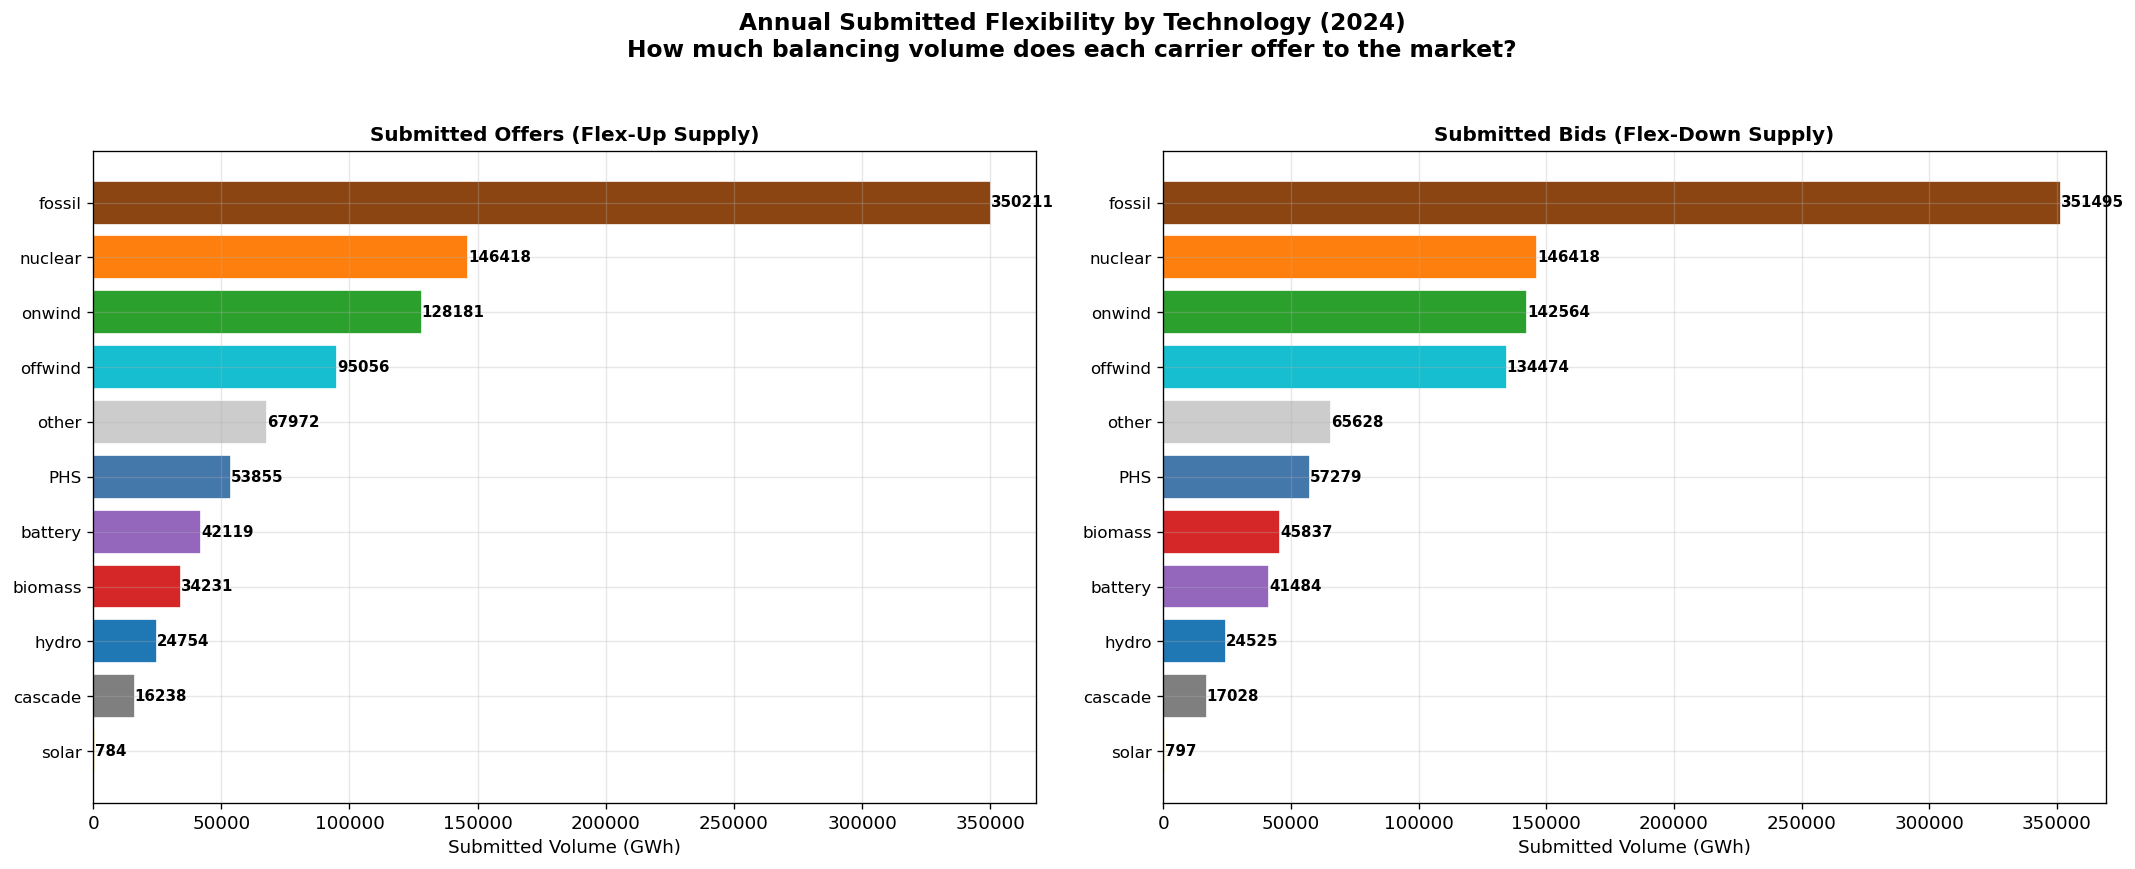

In [ ]:
# Plot 6a: Submitted flexibility by technology

sub_bids_by_carrier = submitted_bid_by_carrier.sort_values(ascending=False) / 1e3
sub_offers_by_carrier = submitted_offer_by_carrier.sort_values(ascending=False) / 1e3

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Offers (flex-up supply)
ax = axes[0]
carriers_offer = sub_offers_by_carrier.index.tolist()
vals_offer = sub_offers_by_carrier.values
colors_o = [CARRIER_COLORS.get(c, '#CCCCCC') for c in carriers_offer]
bars = ax.barh(range(len(carriers_offer)), vals_offer, color=colors_o, edgecolor='white')
ax.set_yticks(range(len(carriers_offer)))
ax.set_yticklabels(carriers_offer, fontsize=10)
ax.set_xlabel('Submitted Volume (GWh)', fontsize=11)
ax.set_title('Submitted Offers (Flex-Up Supply)', fontsize=12, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, vals_offer):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f'{val:.0f}',
            va='center', fontsize=9, fontweight='bold')

# Bids (flex-down supply)
ax = axes[1]
carriers_bid = sub_bids_by_carrier.index.tolist()
vals_bid = sub_bids_by_carrier.values
colors_b = [CARRIER_COLORS.get(c, '#CCCCCC') for c in carriers_bid]
bars = ax.barh(range(len(carriers_bid)), vals_bid, color=colors_b, edgecolor='white')
ax.set_yticks(range(len(carriers_bid)))
ax.set_yticklabels(carriers_bid, fontsize=10)
ax.set_xlabel('Submitted Volume (GWh)', fontsize=11)
ax.set_title('Submitted Bids (Flex-Down Supply)', fontsize=12, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, vals_bid):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f'{val:.0f}',
            va='center', fontsize=9, fontweight='bold')

fig.suptitle('Annual Submitted Flexibility by Technology (2024)\n'
             'How much balancing volume does each carrier offer to the market?',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_submitted_by_tech.png', dpi=150, bbox_inches='tight')
plt.show()


## Plot 6b: Monthly Submitted Flexibility by Technology - Seasonal Supply Curve

How does the flexibility supply from each technology change across the year? Wind offers more flex-down in winter (high output -> more to curtail), while batteries and gas may have more stable year-round profiles. This stacked area chart shows the evolution of the flexibility "menu" available to the clearing algorithm.

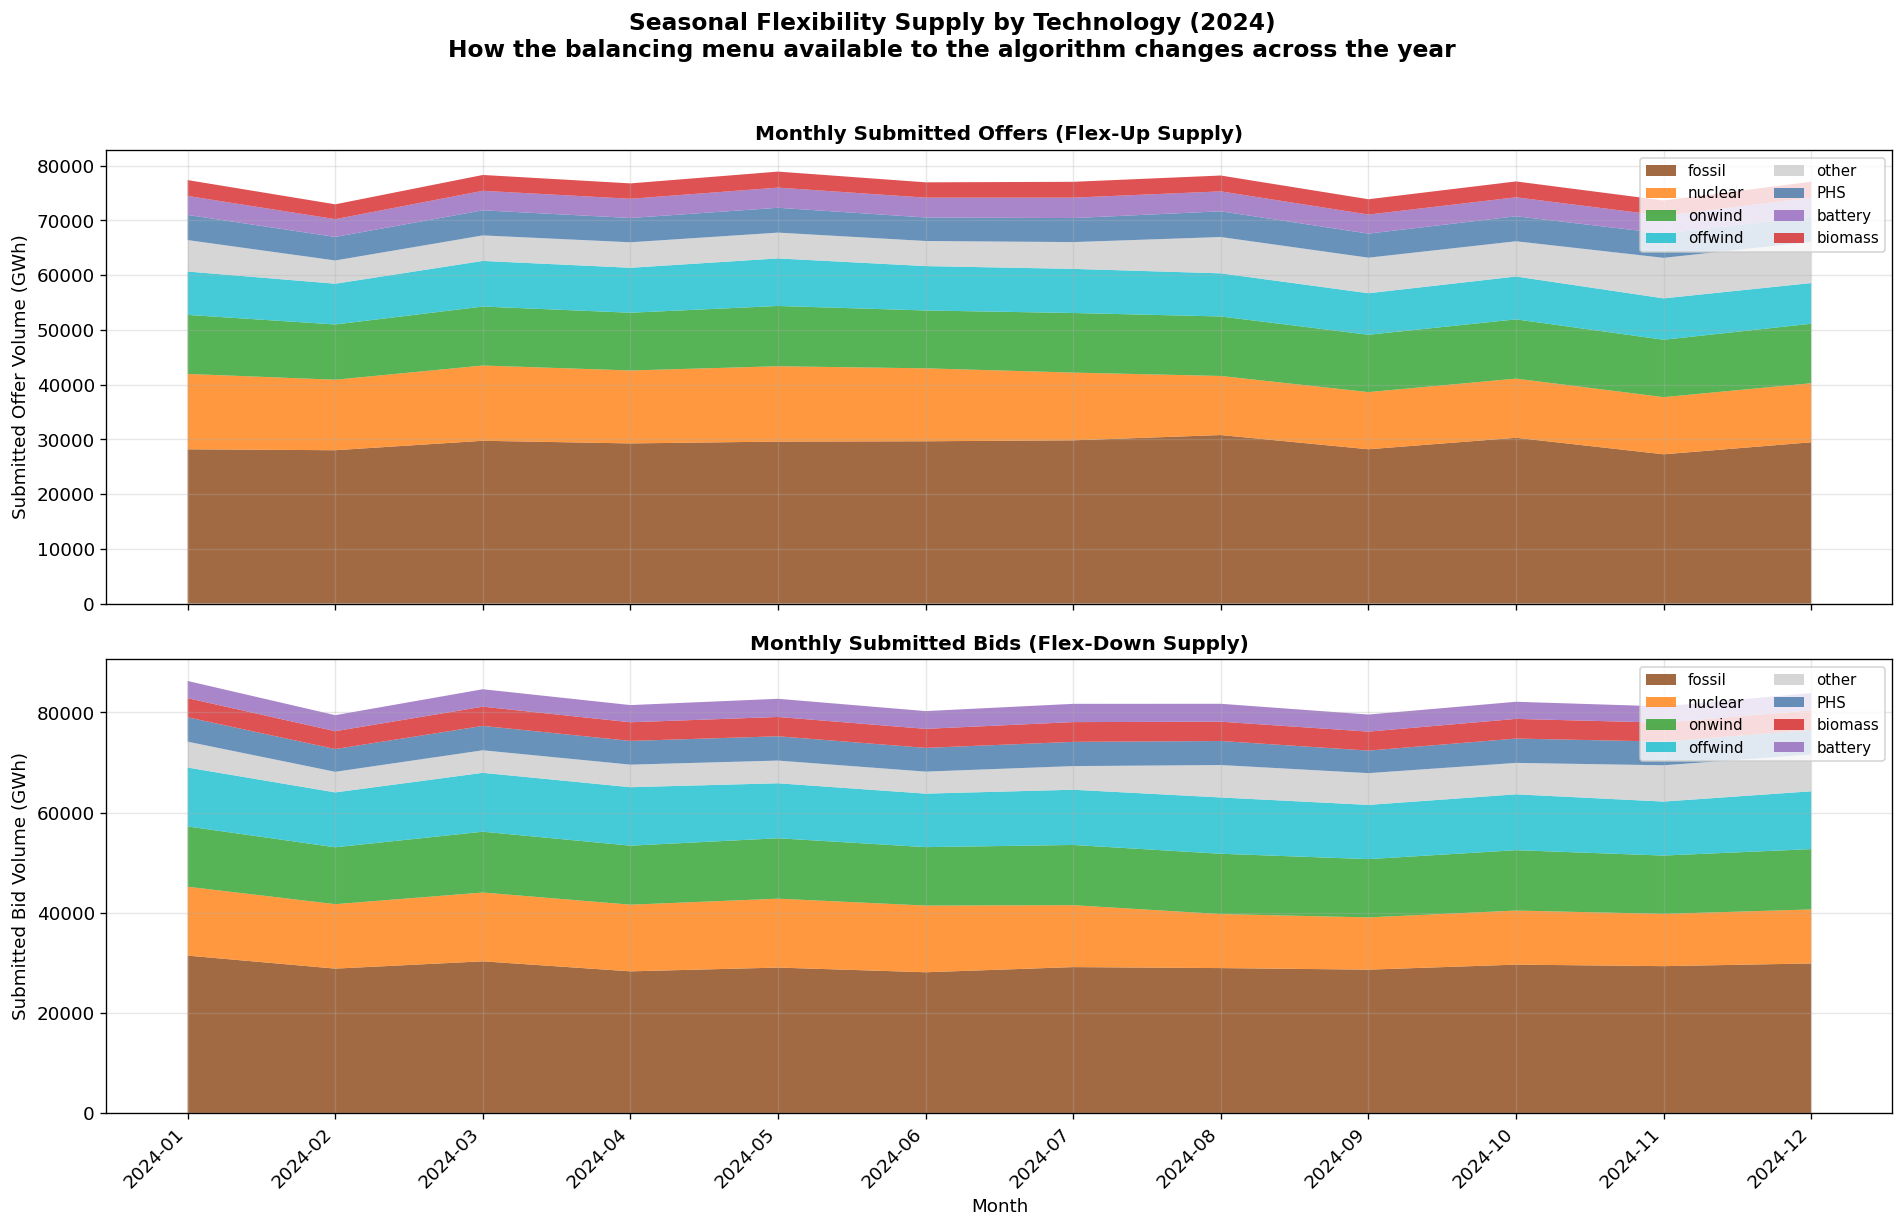

In [ ]:
# Plot 6b: Monthly submitted flexibility by carrier (stacked area)

# Top carriers by total volume
top_carriers = (
    submitted_bid_by_carrier
    .add(submitted_offer_by_carrier, fill_value=0)
    .nlargest(8).index.tolist()
)

# Monthly totals per carrier
monthly_offers = (
    submitted_offer_monthly_carrier[submitted_offer_monthly_carrier['carrier'].isin(top_carriers)]
    .pivot_table(index='month', columns='carrier', values='volume_mwh', aggfunc='sum', fill_value=0)
    .reindex(month_order, fill_value=0) / 1e3
)
monthly_bids = (
    submitted_bid_monthly_carrier[submitted_bid_monthly_carrier['carrier'].isin(top_carriers)]
    .pivot_table(index='month', columns='carrier', values='volume_mwh', aggfunc='sum', fill_value=0)
    .reindex(month_order, fill_value=0) / 1e3
)

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Offers
ax = axes[0]
carrier_order = monthly_offers.sum().sort_values(ascending=False).index.tolist()
monthly_offers = monthly_offers.reindex(columns=carrier_order)
ax.stackplot(range(len(monthly_offers)),
             *[monthly_offers[c].values for c in carrier_order],
             labels=carrier_order,
             colors=[CARRIER_COLORS.get(c, '#CCCCCC') for c in carrier_order],
             alpha=0.8)
ax.set_ylabel('Submitted Offer Volume (GWh)', fontsize=11)
ax.set_title('Monthly Submitted Offers (Flex-Up Supply)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', ncol=2, fontsize=9)

# Bids
ax = axes[1]
carrier_order_b = monthly_bids.sum().sort_values(ascending=False).index.tolist()
monthly_bids = monthly_bids.reindex(columns=carrier_order_b)
ax.stackplot(range(len(monthly_bids)),
             *[monthly_bids[c].values for c in carrier_order_b],
             labels=carrier_order_b,
             colors=[CARRIER_COLORS.get(c, '#CCCCCC') for c in carrier_order_b],
             alpha=0.8)
ax.set_ylabel('Submitted Bid Volume (GWh)', fontsize=11)
ax.set_title('Monthly Submitted Bids (Flex-Down Supply)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', ncol=2, fontsize=9)

ax.set_xticks(range(len(monthly_bids)))
ax.set_xticklabels([str(m) for m in monthly_bids.index], rotation=45, ha='right')
ax.set_xlabel('Month', fontsize=11)

fig.suptitle('Seasonal Flexibility Supply by Technology (2024)\n'
             'How the balancing menu available to the algorithm changes across the year',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_monthly_submitted.png', dpi=150, bbox_inches='tight')
plt.show()


## Plot 6c: Acceptance Rate by Technology - What Fraction of Submitted Volume Gets Cleared?

Comparing submitted volume (from ELEXON API) vs accepted volume (from IV clearing) reveals the **utilisation rate** for each technology. A low acceptance rate means there's plenty of spare capacity; a high rate means that technology is fully utilised and may be a bottleneck.

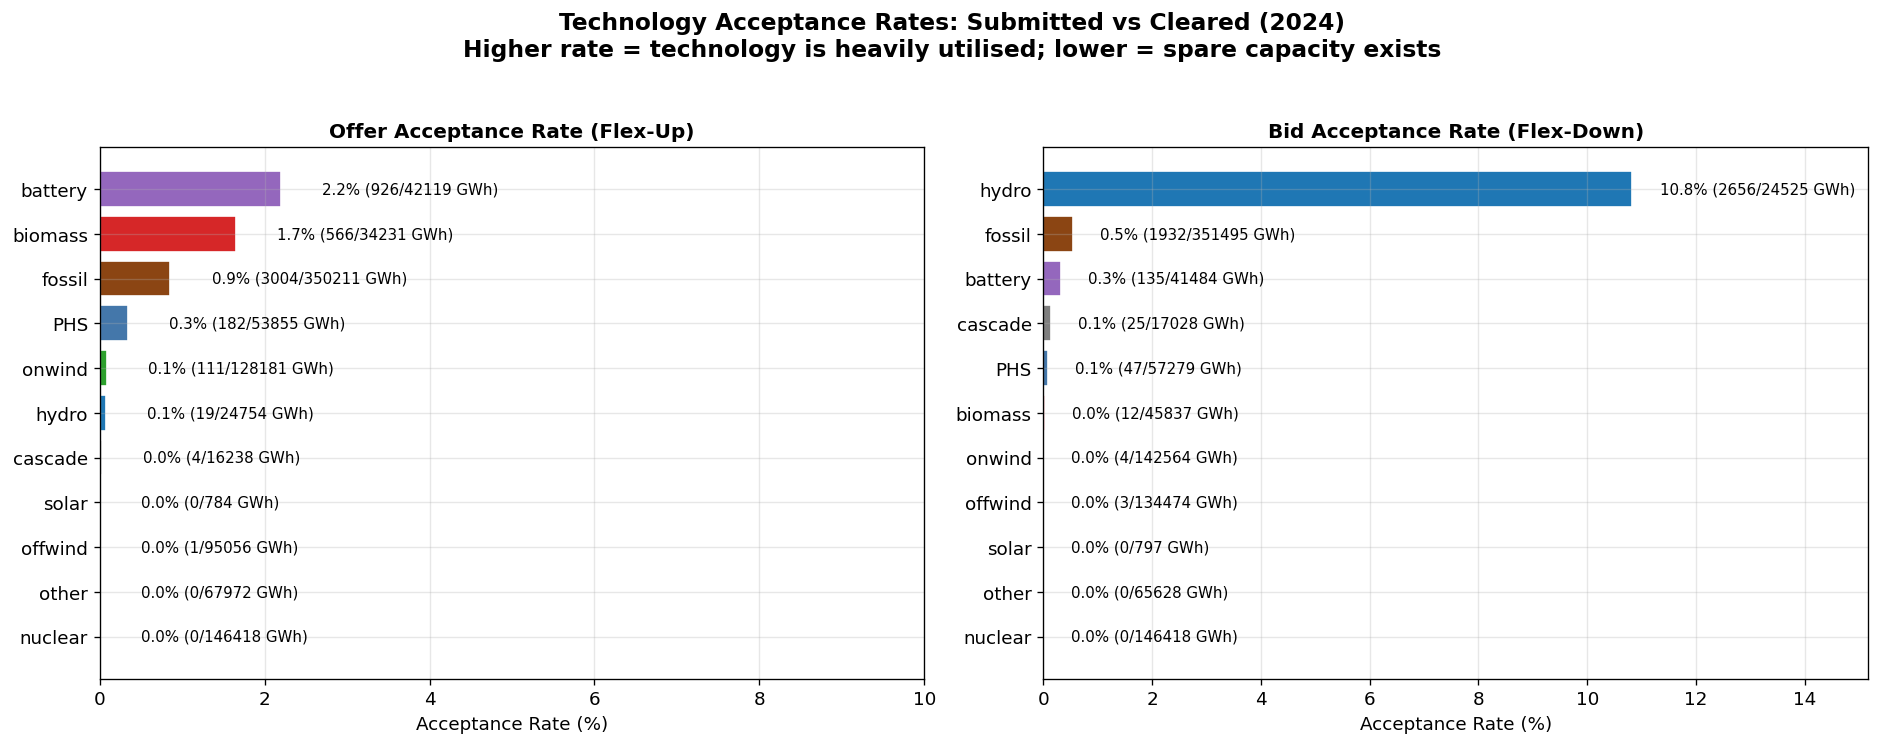

In [ ]:
# Plot 6c: Acceptance rate by technology

# Total submitted per carrier
sub_total = pd.DataFrame({
    'submitted_offers_gwh': submitted_offer_by_carrier / 1e3,
    'submitted_bids_gwh': submitted_bid_by_carrier / 1e3,
})

# Total accepted per carrier (from IV clearing)
acc_offers = iv_actions[iv_actions['action_type'] == 'offer'].groupby('carrier_type')['volume_mwh_actual'].sum() / 1e3
acc_bids = iv_actions[iv_actions['action_type'] == 'bid'].groupby('carrier_type')['volume_mwh_actual'].sum() / 1e3

sub_total['accepted_offers_gwh'] = acc_offers
sub_total['accepted_bids_gwh'] = acc_bids
sub_total = sub_total.fillna(0)

sub_total['offer_accept_rate'] = (sub_total['accepted_offers_gwh'] / sub_total['submitted_offers_gwh'] * 100).clip(0, 100)
sub_total['bid_accept_rate'] = (sub_total['accepted_bids_gwh'] / sub_total['submitted_bids_gwh'] * 100).clip(0, 100)

# Filter to carriers with meaningful volume
sub_total = sub_total[(sub_total['submitted_offers_gwh'] > 1) | (sub_total['submitted_bids_gwh'] > 1)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Offer acceptance rates
ax = axes[0]
data = sub_total.sort_values('offer_accept_rate', ascending=True)
colors = [CARRIER_COLORS.get(c, '#CCCCCC') for c in data.index]
ax.barh(data.index, data['offer_accept_rate'], color=colors, edgecolor='white')
for i, (idx, row) in enumerate(data.iterrows()):
    ax.text(row['offer_accept_rate'] + 0.5, i,
            f"{row['offer_accept_rate']:.1f}% ({row['accepted_offers_gwh']:.0f}/{row['submitted_offers_gwh']:.0f} GWh)",
            va='center', fontsize=9)
ax.set_xlabel('Acceptance Rate (%)', fontsize=11)
ax.set_title('Offer Acceptance Rate (Flex-Up)', fontsize=12, fontweight='bold')
ax.set_xlim(0, max(data['offer_accept_rate'].max() * 1.4, 10))

# Bid acceptance rates
ax = axes[1]
data = sub_total.sort_values('bid_accept_rate', ascending=True)
colors = [CARRIER_COLORS.get(c, '#CCCCCC') for c in data.index]
ax.barh(data.index, data['bid_accept_rate'], color=colors, edgecolor='white')
for i, (idx, row) in enumerate(data.iterrows()):
    ax.text(row['bid_accept_rate'] + 0.5, i,
            f"{row['bid_accept_rate']:.1f}% ({row['accepted_bids_gwh']:.0f}/{row['submitted_bids_gwh']:.0f} GWh)",
            va='center', fontsize=9)
ax.set_xlabel('Acceptance Rate (%)', fontsize=11)
ax.set_title('Bid Acceptance Rate (Flex-Down)', fontsize=12, fontweight='bold')
ax.set_xlim(0, max(data['bid_accept_rate'].max() * 1.4, 10))

fig.suptitle('Technology Acceptance Rates: Submitted vs Cleared (2024)\n'
             'Higher rate = technology is heavily utilised; lower = spare capacity exists',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_acceptance_rate.png', dpi=150, bbox_inches='tight')
plt.show()


## Plot 6d: Flexibility Cost-Volume Landscape - Where Does Each Technology Sit?

A scatter plot showing each technology's **total submitted flexibility** (x-axis, GWh) against its **volume-weighted average submitted price** (y-axis, GBP/MWh). Bubble size reflects the number of unique BMUs offering that technology.

**Reading the chart:**
- **Offers (flex-up):** The SO pays the offer price -> technologies in the **bottom-right** are most attractive (lots of cheap volume). Top-left = expensive and scarce.
- **Bids (flex-down):** A **positive** bid price means the generator pays the SO to turn down (SO receives revenue!) ' technologies in the **top-right** are most attractive (lots of volume + SO gets paid). Technologies with **negative** prices sit below the zero line (SO must pay them to turn down).

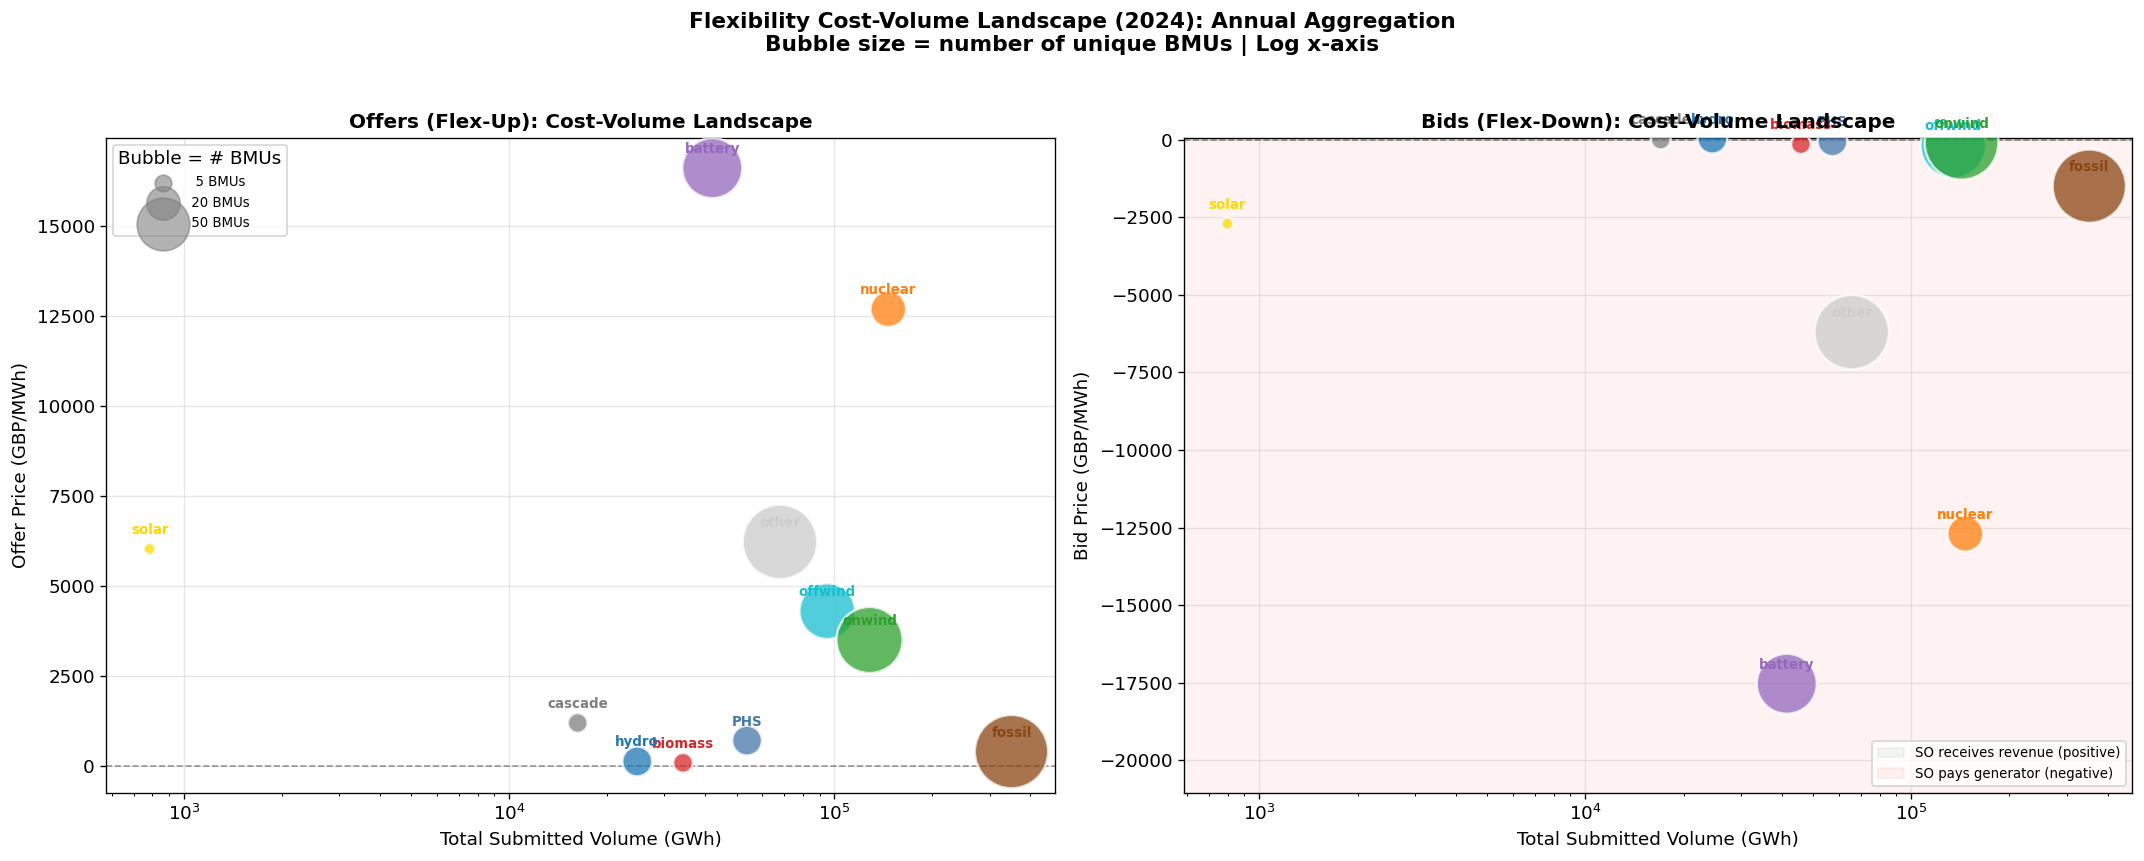


Offer summary (largest volumes):
             total_gwh avg_price n_bmus
carrier 
fossil 350211.031250 411.943848 97
nuclear 146418.000000 12699.638672 23
onwind 128180.656250 3512.021973 79
offwind 95056.257812 4311.918945 56
other 67972.265625 6236.171387 216
PHS 53854.851562 717.652527 16
battery 42119.113281 16614.468750 65
biomass 34230.855469 100.175758 7
hydro 24753.984375 138.884750 16
cascade 16237.540039 1206.407837 7

Bid summary (largest volumes):
             total_gwh avg_price n_bmus
carrier 
fossil 351494.781250 -1501.686890 97
nuclear 146418.000000 -12699.638672 23
onwind 142564.218750 -103.418976 98
offwind 134473.875000 -190.236237 77
other 65627.531250 -6205.020996 215
PHS 57279.148438 -54.708996 16
biomass 45836.757812 -148.412460 7
battery 41483.675781 -17533.376953 65
hydro 24524.644531 30.522896 16
cascade 17027.927734 2.420732 7


In [ ]:
# Plot 6d: Cost-Volume Landscape
# Uses the compact submitted_*_stats tables built in Cell 6a.

# --- Offers aggregation ---
offer_agg = submitted_offer_stats.copy()
offer_agg['total_gwh'] = offer_agg['volume_mwh'] / 1e3
offer_agg['avg_price'] = offer_agg['price_x_vol'] / offer_agg['volume_mw'].clip(lower=1e-9)
offer_agg = offer_agg[offer_agg['total_gwh'] > 1].dropna(subset=['avg_price'])

# --- Bids aggregation ---
bid_agg = submitted_bid_stats.copy()
bid_agg['total_gwh'] = bid_agg['volume_mwh'] / 1e3
bid_agg['avg_price'] = bid_agg['price_x_vol'] / bid_agg['volume_mw'].clip(lower=1e-9)
bid_agg = bid_agg[bid_agg['total_gwh'] > 1].dropna(subset=['avg_price'])

# --- Scatter / bubble chart ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, agg, label, ylbl in [
    (axes[0], offer_agg, 'Offers (Flex-Up)', 'Offer Price (GBP/MWh)'),
    (axes[1], bid_agg, 'Bids (Flex-Down)', 'Bid Price (GBP/MWh)'),
]:
    xs = agg['total_gwh'].values
    ys = agg['avg_price'].values
    sizes = np.clip(agg['n_bmus'].values * 20, 50, 2000)
    colors = [CARRIER_COLORS.get(c, '#CCCCCC') for c in agg.index]

    ax.scatter(xs, ys, s=sizes, c=colors, alpha=0.75,
               edgecolors='white', linewidth=1.5, zorder=3)
    ax.axhline(0, color='#555555', linewidth=1.0, linestyle='--', alpha=0.6)

    for c, x, y in zip(agg.index, xs, ys):
        ax.annotate(c, (x, y), textcoords='offset points',
                    xytext=(0, 9), ha='center', fontsize=8, fontweight='bold',
                    color=CARRIER_COLORS.get(c, '#333333'))

    ax.set_xlabel('Total Submitted Volume (GWh)', fontsize=11)
    ax.set_ylabel(ylbl, fontsize=11)
    ax.set_title(f'{label}: Cost-Volume Landscape', fontsize=12, fontweight='bold')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)

    if 'Bid' in label:
        ymax = max(float(ys.max()) * 1.2, 10)
        ymin = min(float(ys.min()) * 1.2, -10)
        ax.axhspan(0, ymax, alpha=0.05, color='green', zorder=0,
                   label='SO receives revenue (positive)')
        ax.axhspan(ymin, 0, alpha=0.05, color='red', zorder=0,
                   label='SO pays generator (negative)')
        ax.set_ylim(ymin, ymax)
        ax.legend(fontsize=8, loc='lower right')

# Bubble-size legend on offer panel
size_handles = [
    plt.scatter([], [], s=100, c='grey', alpha=0.6, label=' 5 BMUs'),
    plt.scatter([], [], s=400, c='grey', alpha=0.6, label=' 20 BMUs'),
    plt.scatter([], [], s=1000, c='grey', alpha=0.6, label=' 50 BMUs'),
]
axes[0].legend(handles=size_handles, title='Bubble = # BMUs', fontsize=8, loc='upper left')

fig.suptitle('Flexibility Cost-Volume Landscape (2024): Annual Aggregation\n'
             'Bubble size = number of unique BMUs | Log x-axis',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_cost_volume_landscape.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nOffer summary (largest volumes):')
print(offer_agg[['total_gwh', 'avg_price', 'n_bmus']].sort_values('total_gwh', ascending=False)
      .head(10).to_string())
print('\nBid summary (largest volumes):')
print(bid_agg[['total_gwh', 'avg_price', 'n_bmus']].sort_values('total_gwh', ascending=False)
      .head(10).to_string())


## Plot 6e: Monthly "Flexibility Value Score" - Volume Adjusted for Price Attractiveness

Plot 6d showed the annual picture. But how does each technology's *helpfulness* change across the year?

We define a **Flexibility Value Score (FVS)** that combines volume AND price into a single metric measuring how much useful, cost-effective flexibility each technology provides:

$$\text{FVS}_{\text{offers}} = V \times e^{-p/100}$$
$$\text{FVS}_{\text{bids}} = V \times e^{+p/100}$$

where $V$ = submitted volume (GWh) and $p$ = volume-weighted avg price (GBP/MWh).

**Interpretation:** FVS converts actual volume into *"equivalent GWh of free flexibility"*:
- **Offers** at GBP0/MWh -> FVS = full volume (free flex - ideal). At GBP100/MWh -> FVS ~ 37% of volume. At GBP200 -> 14%.
- **Bids** at +GBP100/MWh (SO gets paid!) ' FVS = 2.7 - volume (massive bonus). At GBP0 -> FVS = volume. At 'GBP100 -> FVS ~ 37% of volume.

The exponential weighting naturally handles both positive and negative bid prices without arbitrary reference values, and captures the SO's perspective: cheap flex-up is valuable, and flex-down that *pays* the SO is even more valuable than free.

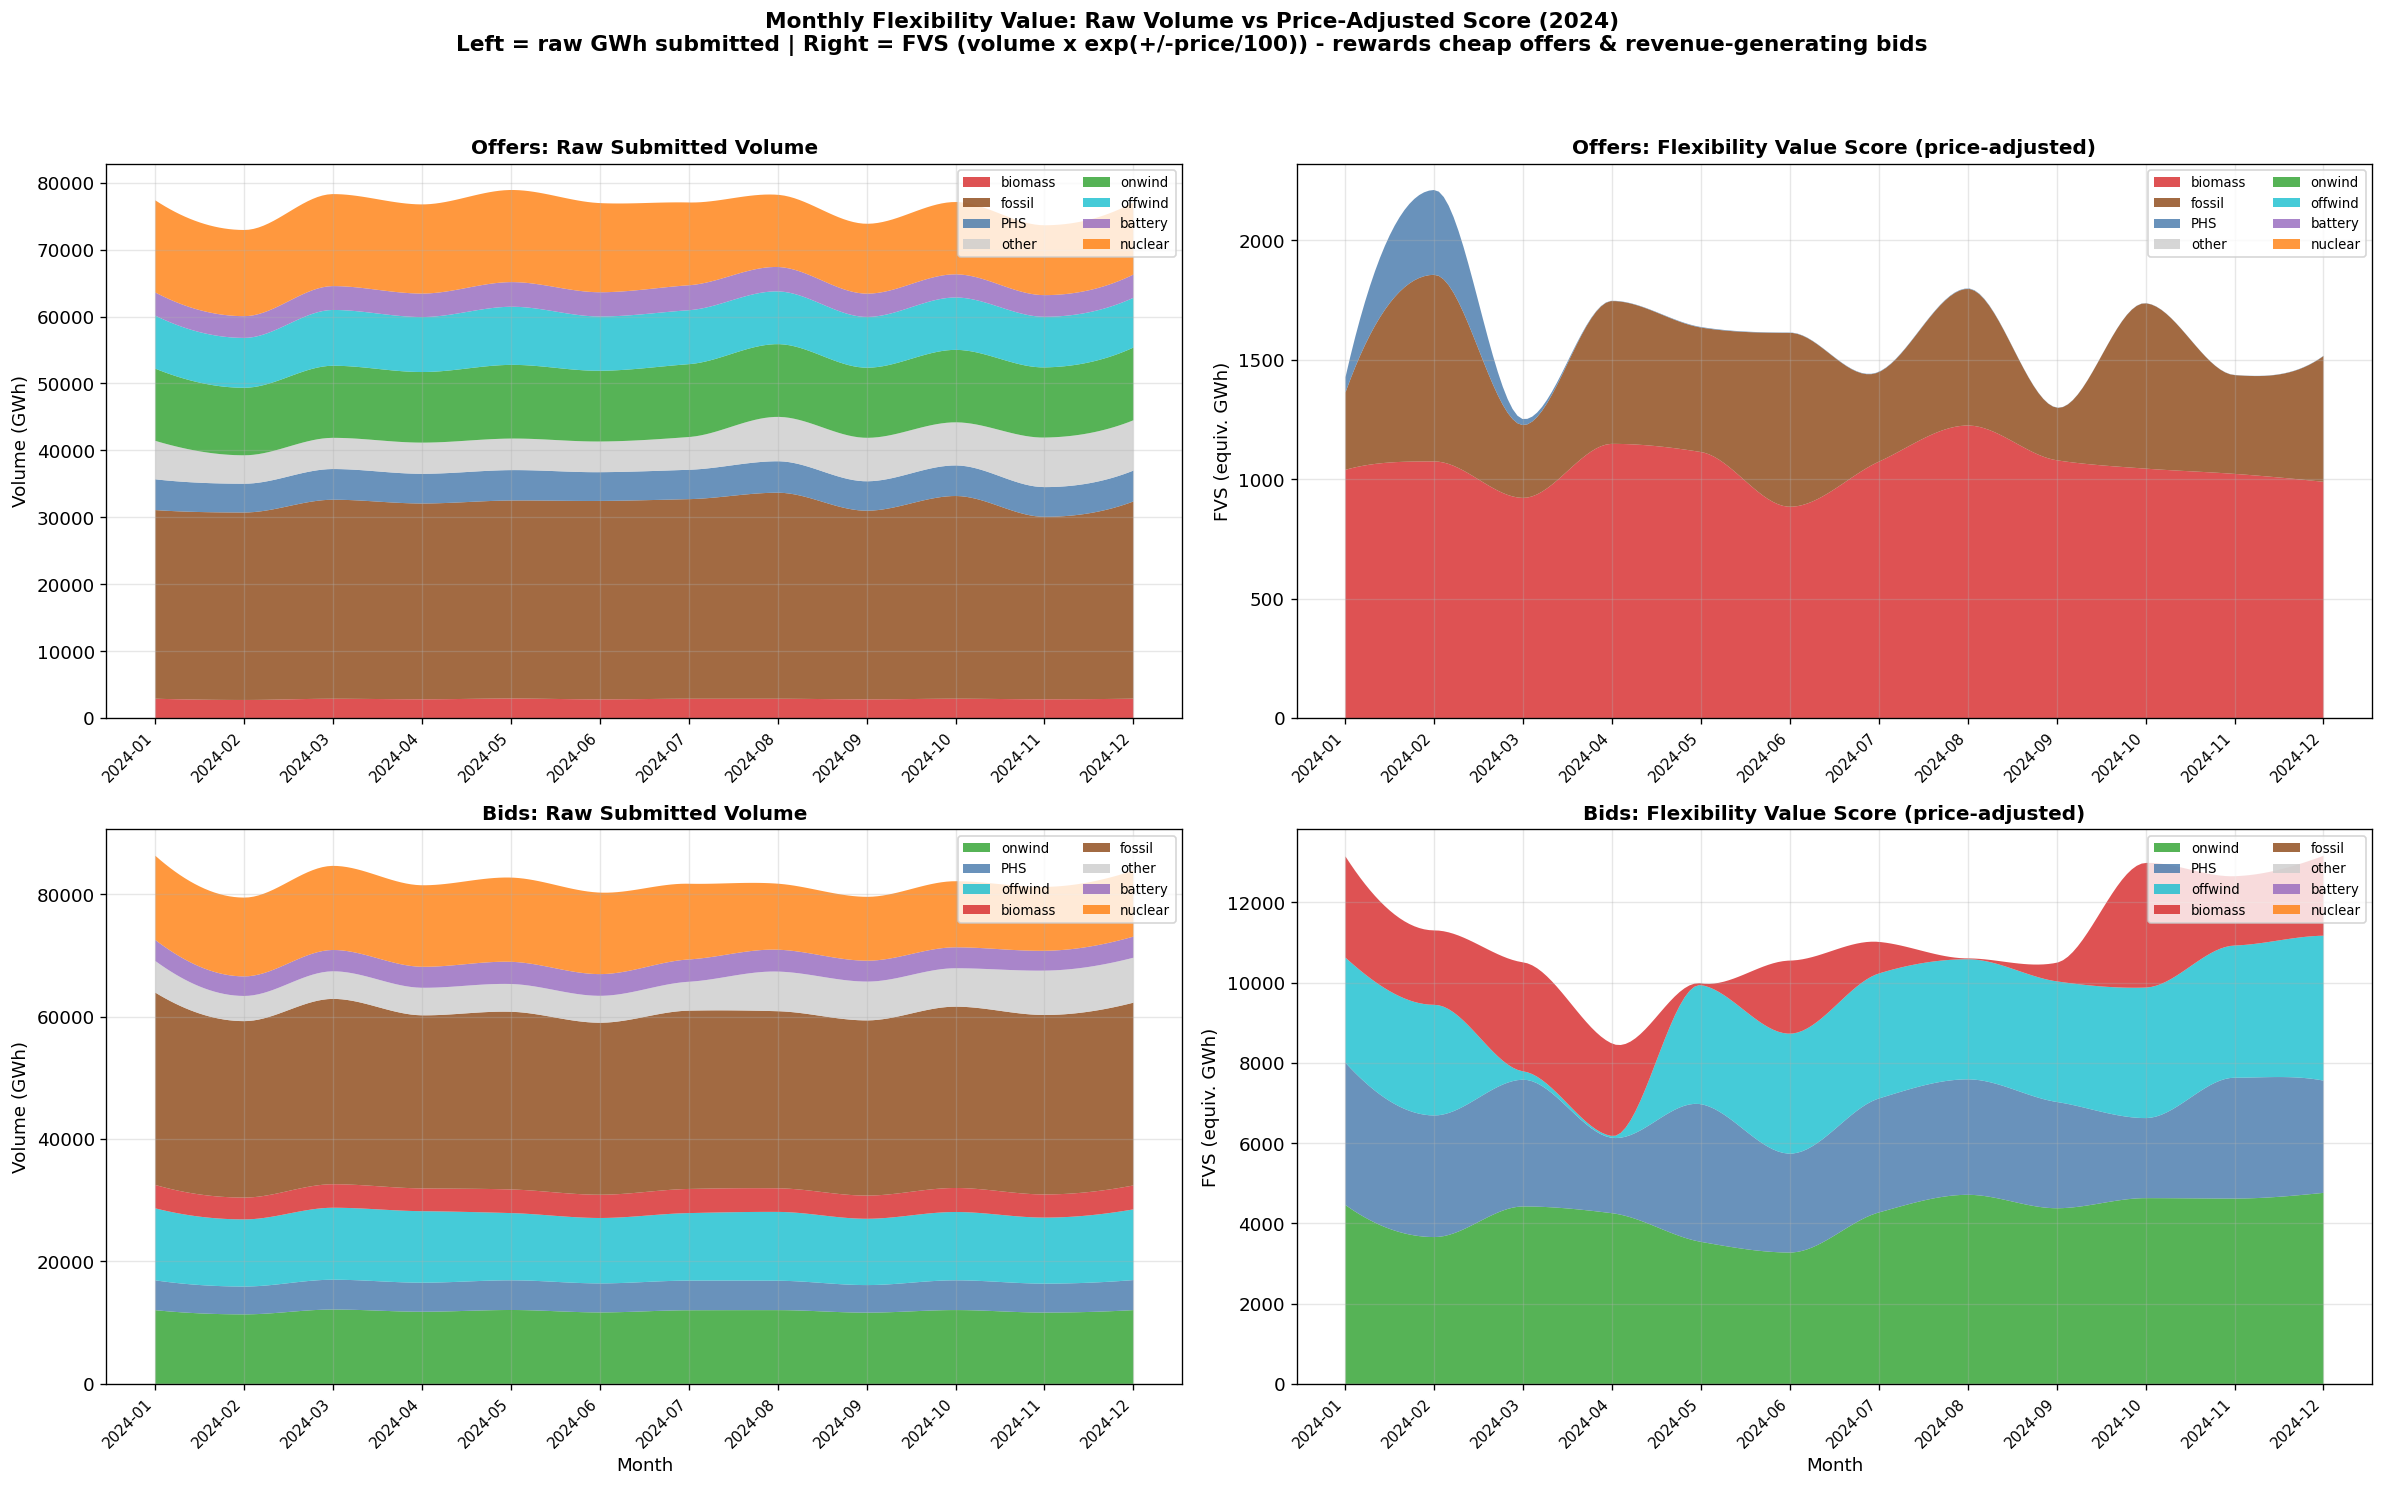

Annual FVS ranking (offers - higher = more helpful for SO):
  biomass Vol: 34231 GWh -> FVS: 12618 equiv GWh (x0.37 - PENALISED)
  fossil Vol: 350211 GWh -> FVS: 6057 equiv GWh (x0.02 - PENALISED)
  PHS Vol: 53855 GWh -> FVS: 456 equiv GWh (x0.01 - PENALISED)
  other Vol: 67972 GWh -> FVS: 0 equiv GWh (x0.00 - PENALISED)
  onwind Vol: 128181 GWh -> FVS: 0 equiv GWh (x0.00 - PENALISED)
  offwind Vol: 95056 GWh -> FVS: 0 equiv GWh (x0.00 - PENALISED)
  battery Vol: 42119 GWh -> FVS: 0 equiv GWh (x0.00 - PENALISED)
  nuclear Vol: 146418 GWh -> FVS: 0 equiv GWh (x0.00 - PENALISED)

Annual FVS ranking (bids - higher = more helpful for SO):
  onwind Vol: 142564 GWh -> FVS: 50981 equiv GWh (x0.36)
  PHS Vol: 57279 GWh -> FVS: 33686 equiv GWh (x0.59)
  offwind Vol: 134474 GWh -> FVS: 30869 equiv GWh (x0.23)
  biomass Vol: 45837 GWh -> FVS: 19364 equiv GWh (x0.42)
  fossil Vol: 351495 GWh -> FVS: 2 equiv GWh (x0.00)
  other Vol: 65628 GWh -> FVS: 0 equiv GWh (x0.00)
  battery Vol: 41484 GWh -> 

In [ ]:
# Plot 6e: Monthly Flexibility Value Score (FVS)
# Uses the compact monthly submitted carrier aggregates built in Cell 6a.

# --- Offers: monthly FVS by carrier ---
offer_monthly_carrier = submitted_offer_monthly_carrier[
    submitted_offer_monthly_carrier['carrier'].isin(top_carriers)
].copy()
offer_monthly_carrier['volume_gwh'] = offer_monthly_carrier['volume_mwh'] / 1e3
offer_monthly_carrier['avg_price'] = (
    offer_monthly_carrier['price_x_vol'] / offer_monthly_carrier['volume_mw'].clip(lower=1e-9)
)
offer_monthly_carrier['fvs'] = (
    offer_monthly_carrier['volume_gwh'] * np.exp(-offer_monthly_carrier['avg_price'] / 100)
)

# --- Bids: monthly FVS by carrier ---
bid_monthly_carrier = submitted_bid_monthly_carrier[
    submitted_bid_monthly_carrier['carrier'].isin(top_carriers)
].copy()
bid_monthly_carrier['volume_gwh'] = bid_monthly_carrier['volume_mwh'] / 1e3
bid_monthly_carrier['avg_price'] = (
    bid_monthly_carrier['price_x_vol'] / bid_monthly_carrier['volume_mw'].clip(lower=1e-9)
)
# Positive bid price = SO receives revenue -> exponential BOOST to FVS
bid_monthly_carrier['fvs'] = (
    bid_monthly_carrier['volume_gwh'] * np.exp(bid_monthly_carrier['avg_price'] / 100)
)

# --- Pivot for stacked area charts ---
pivot_offer_fvs = offer_monthly_carrier.pivot_table(
    index='month', columns='carrier', values='fvs', fill_value=0).reindex(month_order, fill_value=0)
pivot_bid_fvs = bid_monthly_carrier.pivot_table(
    index='month', columns='carrier', values='fvs', fill_value=0).reindex(month_order, fill_value=0)
pivot_offer_vol = offer_monthly_carrier.pivot_table(
    index='month', columns='carrier', values='volume_gwh', fill_value=0).reindex(month_order, fill_value=0)
pivot_bid_vol = bid_monthly_carrier.pivot_table(
    index='month', columns='carrier', values='volume_gwh', fill_value=0).reindex(month_order, fill_value=0)

# Sort carriers by total annual FVS
offer_carrier_order = pivot_offer_fvs.sum().sort_values(ascending=False).index.tolist()
bid_carrier_order = pivot_bid_fvs.sum().sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

from scipy.interpolate import PchipInterpolator
x_orig = np.arange(len(pivot_offer_fvs))
x_fine = np.linspace(0, len(pivot_offer_fvs) - 1, 200)


def smooth_stackplot(ax, pivot_df, carrier_order, x_orig, x_fine, colors_dict, title, ylabel):
    smooth_data, labels, colors = [], [], []
    for c in carrier_order:
        if c not in pivot_df.columns:
            continue
        y = pivot_df[c].values.astype(float)
        y_smooth = np.clip(PchipInterpolator(x_orig, y)(x_fine), 0, None)
        smooth_data.append(y_smooth)
        labels.append(c)
        colors.append(colors_dict.get(c, '#CCCCCC'))
    ax.stackplot(x_fine, *smooth_data, labels=labels, colors=colors, alpha=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.set_xticks(x_orig)
    ax.set_xticklabels([str(m) for m in pivot_df.index], rotation=45, ha='right', fontsize=9)


smooth_stackplot(axes[0, 0], pivot_offer_vol, offer_carrier_order, x_orig, x_fine,
                 CARRIER_COLORS, 'Offers: Raw Submitted Volume', 'Volume (GWh)')
smooth_stackplot(axes[0, 1], pivot_offer_fvs, offer_carrier_order, x_orig, x_fine,
                 CARRIER_COLORS, 'Offers: Flexibility Value Score (price-adjusted)', 'FVS (equiv. GWh)')
smooth_stackplot(axes[1, 0], pivot_bid_vol, bid_carrier_order, x_orig, x_fine,
                 CARRIER_COLORS, 'Bids: Raw Submitted Volume', 'Volume (GWh)')
smooth_stackplot(axes[1, 1], pivot_bid_fvs, bid_carrier_order, x_orig, x_fine,
                 CARRIER_COLORS, 'Bids: Flexibility Value Score (price-adjusted)', 'FVS (equiv. GWh)')

axes[1, 0].set_xlabel('Month', fontsize=11)
axes[1, 1].set_xlabel('Month', fontsize=11)

fig.suptitle('Monthly Flexibility Value: Raw Volume vs Price-Adjusted Score (2024)\n'
             'Left = raw GWh submitted | Right = FVS (volume x exp(+/-price/100)) - '
             'rewards cheap offers & revenue-generating bids',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_flexibility_value_score.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Annual ranking summary ---
_bid_annual = bid_monthly_carrier.groupby('carrier')[['price_x_vol', 'volume_mw']].sum()
annual_bid_avg_price = _bid_annual['price_x_vol'] / _bid_annual['volume_mw'].clip(lower=1e-9)

print('Annual FVS ranking (offers - higher = more helpful for SO):')
annual_offer_fvs = pivot_offer_fvs.sum().sort_values(ascending=False)
annual_offer_vol = pivot_offer_vol.sum().reindex(annual_offer_fvs.index)
for c in annual_offer_fvs.index:
    ratio = annual_offer_fvs[c] / annual_offer_vol[c] if annual_offer_vol[c] > 0 else 0
    boost_flag = 'BOOSTED' if ratio > 1 else 'PENALISED'
    print(f' {c:15s} Vol: {annual_offer_vol[c]:7.0f} GWh -> FVS: {annual_offer_fvs[c]:7.0f} '
          f'equiv GWh (x{ratio:.2f} - {boost_flag})')

print('\nAnnual FVS ranking (bids - higher = more helpful for SO):')
annual_bid_fvs = pivot_bid_fvs.sum().sort_values(ascending=False)
annual_bid_vol = pivot_bid_vol.sum().reindex(annual_bid_fvs.index)
for c in annual_bid_fvs.index:
    ratio = annual_bid_fvs[c] / annual_bid_vol[c] if annual_bid_vol[c] > 0 else 0
    avg_p = annual_bid_avg_price.get(c, 0)
    sign_note = ' <- SO gets PAID!' if avg_p > 0 else ''
    print(f' {c:15s} Vol: {annual_bid_vol[c]:7.0f} GWh -> FVS: {annual_bid_fvs[c]:7.0f} '
          f'equiv GWh (x{ratio:.2f}){sign_note}')


---
# Section 7 - Data Scale & Model Performance

> *"Just how much data did this model process?"*

These final plots quantify the sheer volume of data science work behind the IV model extension - millions of bid/offer rows retrieved from the ELEXON API, hundreds of network optimisations solved, and the operational performance of the clearing algorithm across 366 days.

## Plot 7a: Raw Data Volume Statistics

A summary of the total data processed: number of API calls, rows of bids/offers, settlement periods cleared, networks solved, etc.

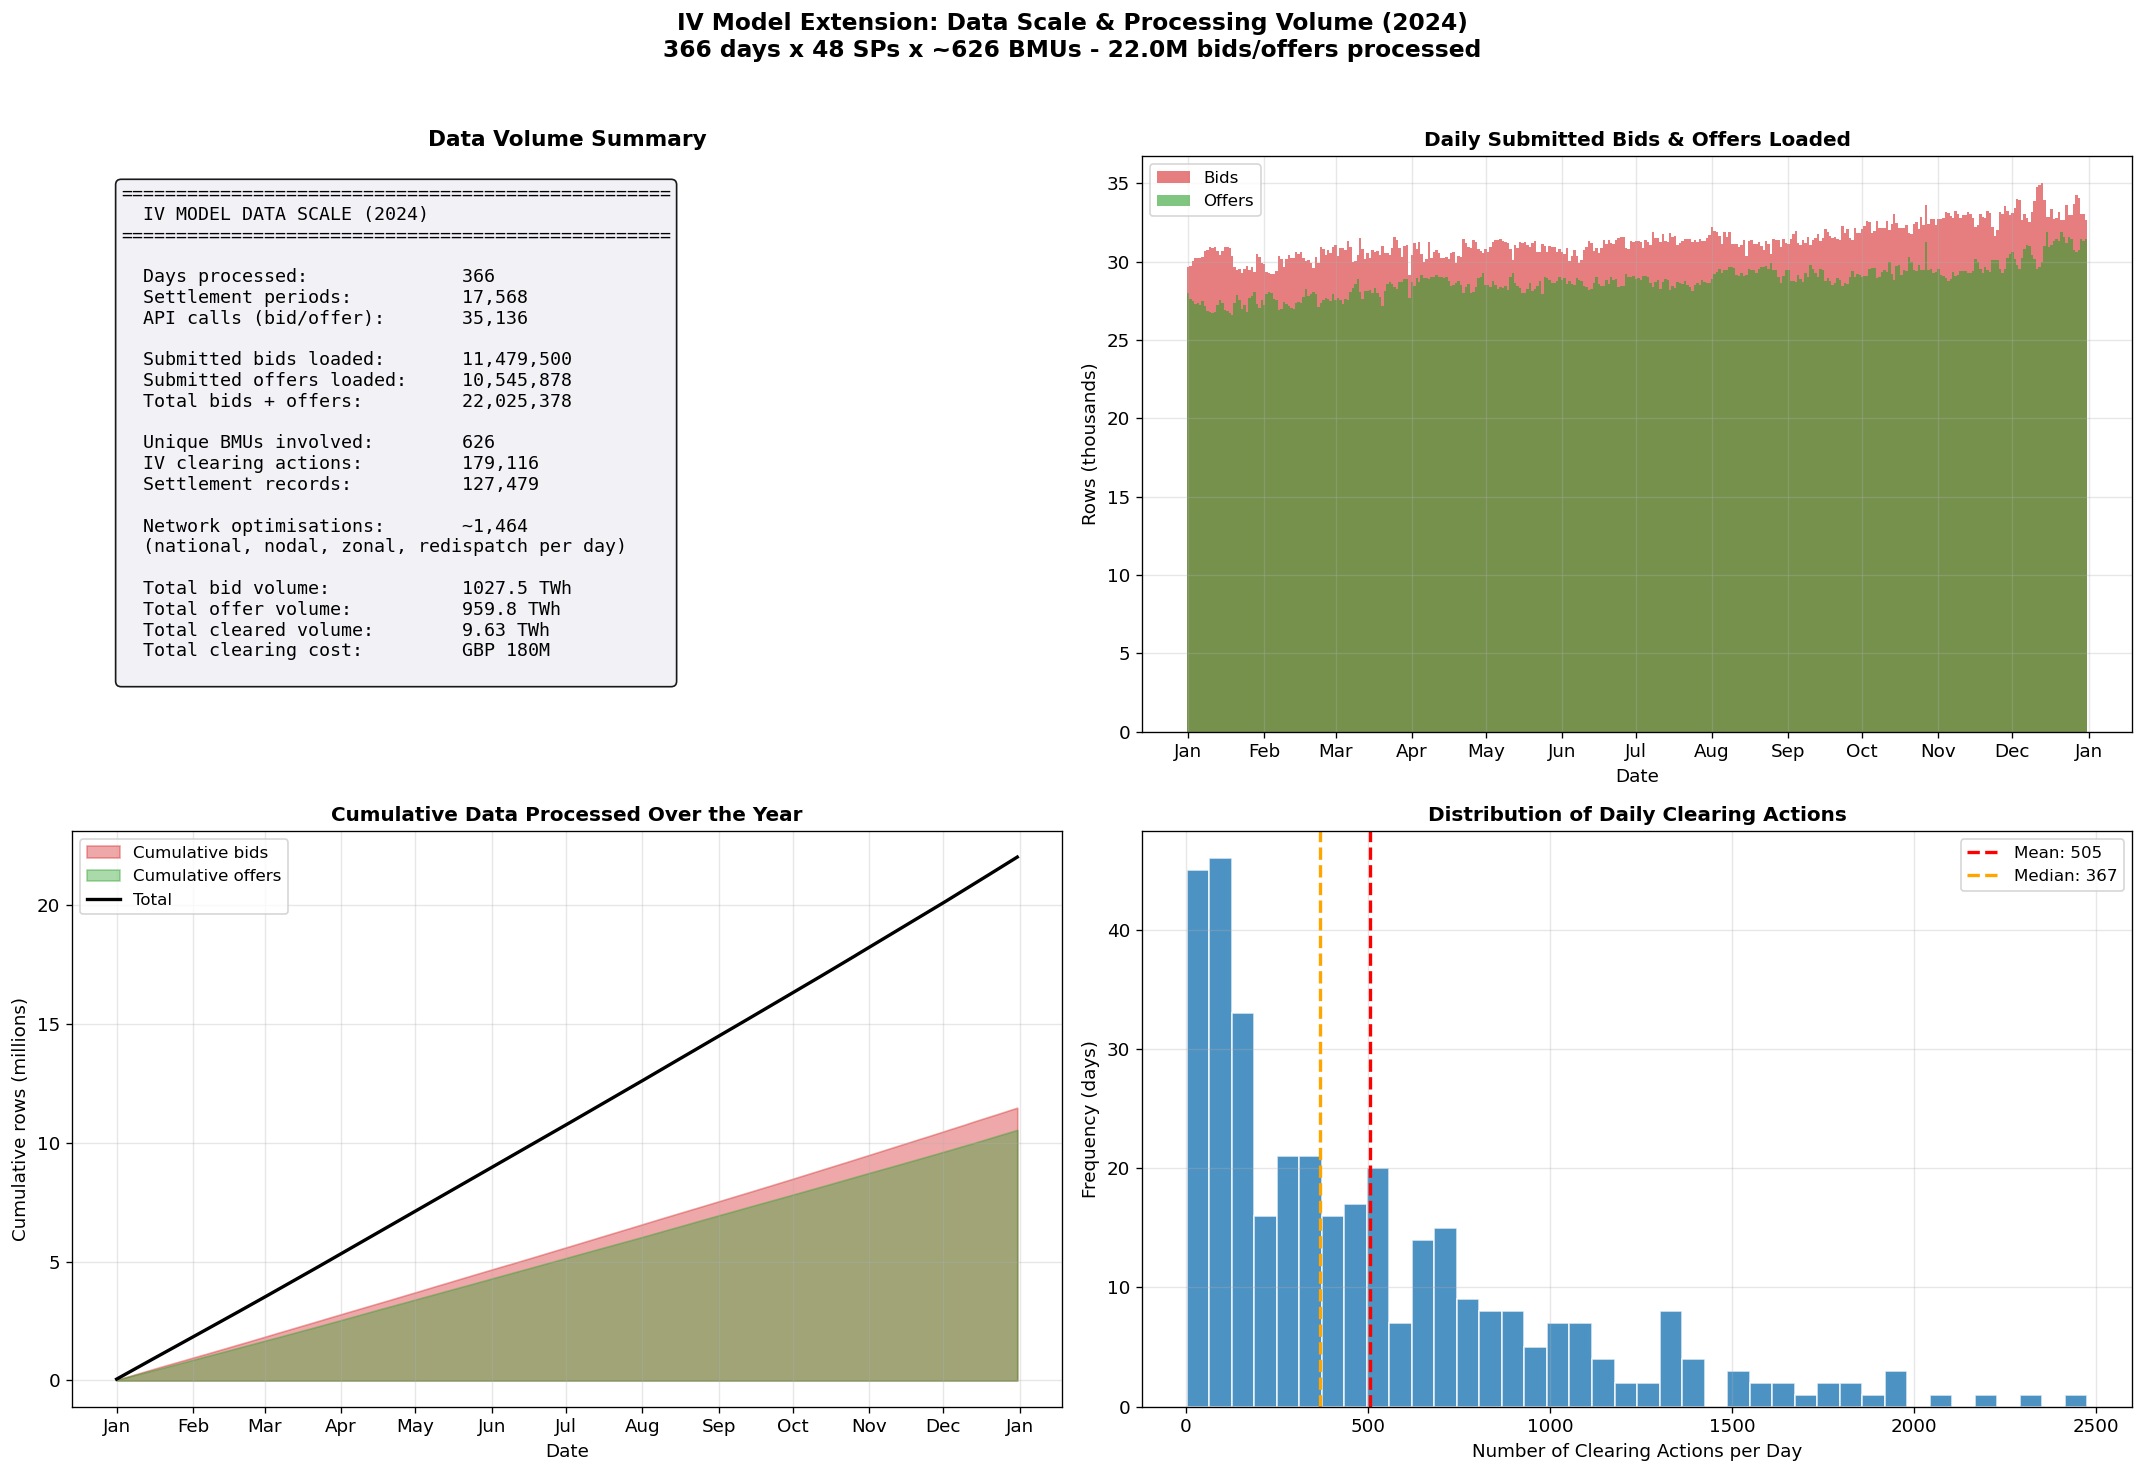

In [ ]:
# Plot 7a: Data volume summary

# Calculate key metrics
n_days = len(all_dates)
n_bids_total = n_submitted_bids
n_offers_total = n_submitted_offers
n_bids_offers_total = n_bids_total + n_offers_total
n_clearing_actions = len(iv_actions)
n_settlement_rows = len(settle)
n_unique_bmus_bids = n_unique_bmus_bids
n_unique_bmus_offers = n_unique_bmus_offers
n_unique_bmus = n_unique_bmus
n_sps_per_day = 48 # half-hourly
n_total_sps = n_days * n_sps_per_day
n_api_calls = n_total_sps
n_networks_solved = n_days * 4

# Daily data volumes
daily_bids = daily_submitted_bids
daily_offers = daily_submitted_offers

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Panel 1: Summary statistics as text
ax = axes[0, 0]
ax.axis('off')
stats_text = (
    f"{'='*50}\n"
    f" IV MODEL DATA SCALE (2024)\n"
    f"{'='*50}\n\n"
    f" Days processed: {n_days:,}\n"
    f" Settlement periods: {n_total_sps:,}\n"
    f" API calls (bid/offer): {n_total_sps * 2:,}\n\n"
    f" Submitted bids loaded: {n_bids_total:,.0f}\n"
    f" Submitted offers loaded: {n_offers_total:,.0f}\n"
    f" Total bids + offers: {n_bids_offers_total:,.0f}\n\n"
    f" Unique BMUs involved: {n_unique_bmus:,}\n"
    f" IV clearing actions: {n_clearing_actions:,}\n"
    f" Settlement records: {n_settlement_rows:,}\n\n"
    f" Network optimisations: ~{n_networks_solved:,}\n"
    f" (national, nodal, zonal, redispatch per day)\n\n"
    f" Total bid volume: {submitted_bid_by_carrier.sum()/1e6:.1f} TWh\n"
    f" Total offer volume: {submitted_offer_by_carrier.sum()/1e6:.1f} TWh\n"
    f" Total cleared volume: {iv_actions['volume_mwh_actual'].sum()/1e6:.2f} TWh\n"
    f" Total clearing cost: GBP {iv_actions['cost_gbp'].sum()/1e6:.0f}M\n"
)
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=11, fontfamily='monospace',
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='#f0f0f5', alpha=0.9))
ax.set_title('Data Volume Summary', fontsize=13, fontweight='bold')

# Panel 2: Daily bid/offer volume
ax = axes[0, 1]
ax.bar(daily_bids.index, daily_bids.values / 1e3, alpha=0.6, label='Bids', color='#d62728', width=1)
ax.bar(daily_offers.index, daily_offers.values / 1e3, alpha=0.6, label='Offers', color='#2ca02c', width=1)
ax.set_xlabel('Date')
ax.set_ylabel('Rows (thousands)')
ax.set_title('Daily Submitted Bids & Offers Loaded', fontsize=12, fontweight='bold')
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Panel 3: Cumulative data growth
ax = axes[1, 0]
cum_bids = daily_bids.sort_index().cumsum() / 1e6
cum_offers = daily_offers.sort_index().cumsum() / 1e6
ax.fill_between(cum_bids.index, cum_bids.values, alpha=0.4, color='#d62728', label='Cumulative bids')
ax.fill_between(cum_offers.index, cum_offers.values, alpha=0.4, color='#2ca02c', label='Cumulative offers')
ax.plot(cum_bids.index, (cum_bids + cum_offers).values, 'k-', linewidth=2, label='Total')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative rows (millions)')
ax.set_title('Cumulative Data Processed Over the Year', fontsize=12, fontweight='bold')
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Panel 4: Distribution of daily clearing actions
ax = axes[1, 1]
daily_clearing = iv_actions.groupby('date').size()
ax.hist(daily_clearing.values, bins=40, color='#1f77b4', edgecolor='white', alpha=0.8)
ax.axvline(daily_clearing.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {daily_clearing.mean():.0f}')
ax.axvline(daily_clearing.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {daily_clearing.median():.0f}')
ax.set_xlabel('Number of Clearing Actions per Day')
ax.set_ylabel('Frequency (days)')
ax.set_title('Distribution of Daily Clearing Actions', fontsize=12, fontweight='bold')
ax.legend()

fig.suptitle('IV Model Extension: Data Scale & Processing Volume (2024)\n'
             f'366 days x 48 SPs x ~{n_unique_bmus} BMUs - {n_bids_offers_total/1e6:.1f}M bids/offers processed',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_data_scale.png', dpi=150, bbox_inches='tight')
plt.show()


## Plot 7b: Clearing Algorithm Performance - Uncleared Volumes & Success Rates

How often does the clearing algorithm **fully clear** all required balancing volumes? When it can't clear (insufficient bids/offers), how much volume remains uncleared, and in which zones? This is a critical measure of the model's operational capability.

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


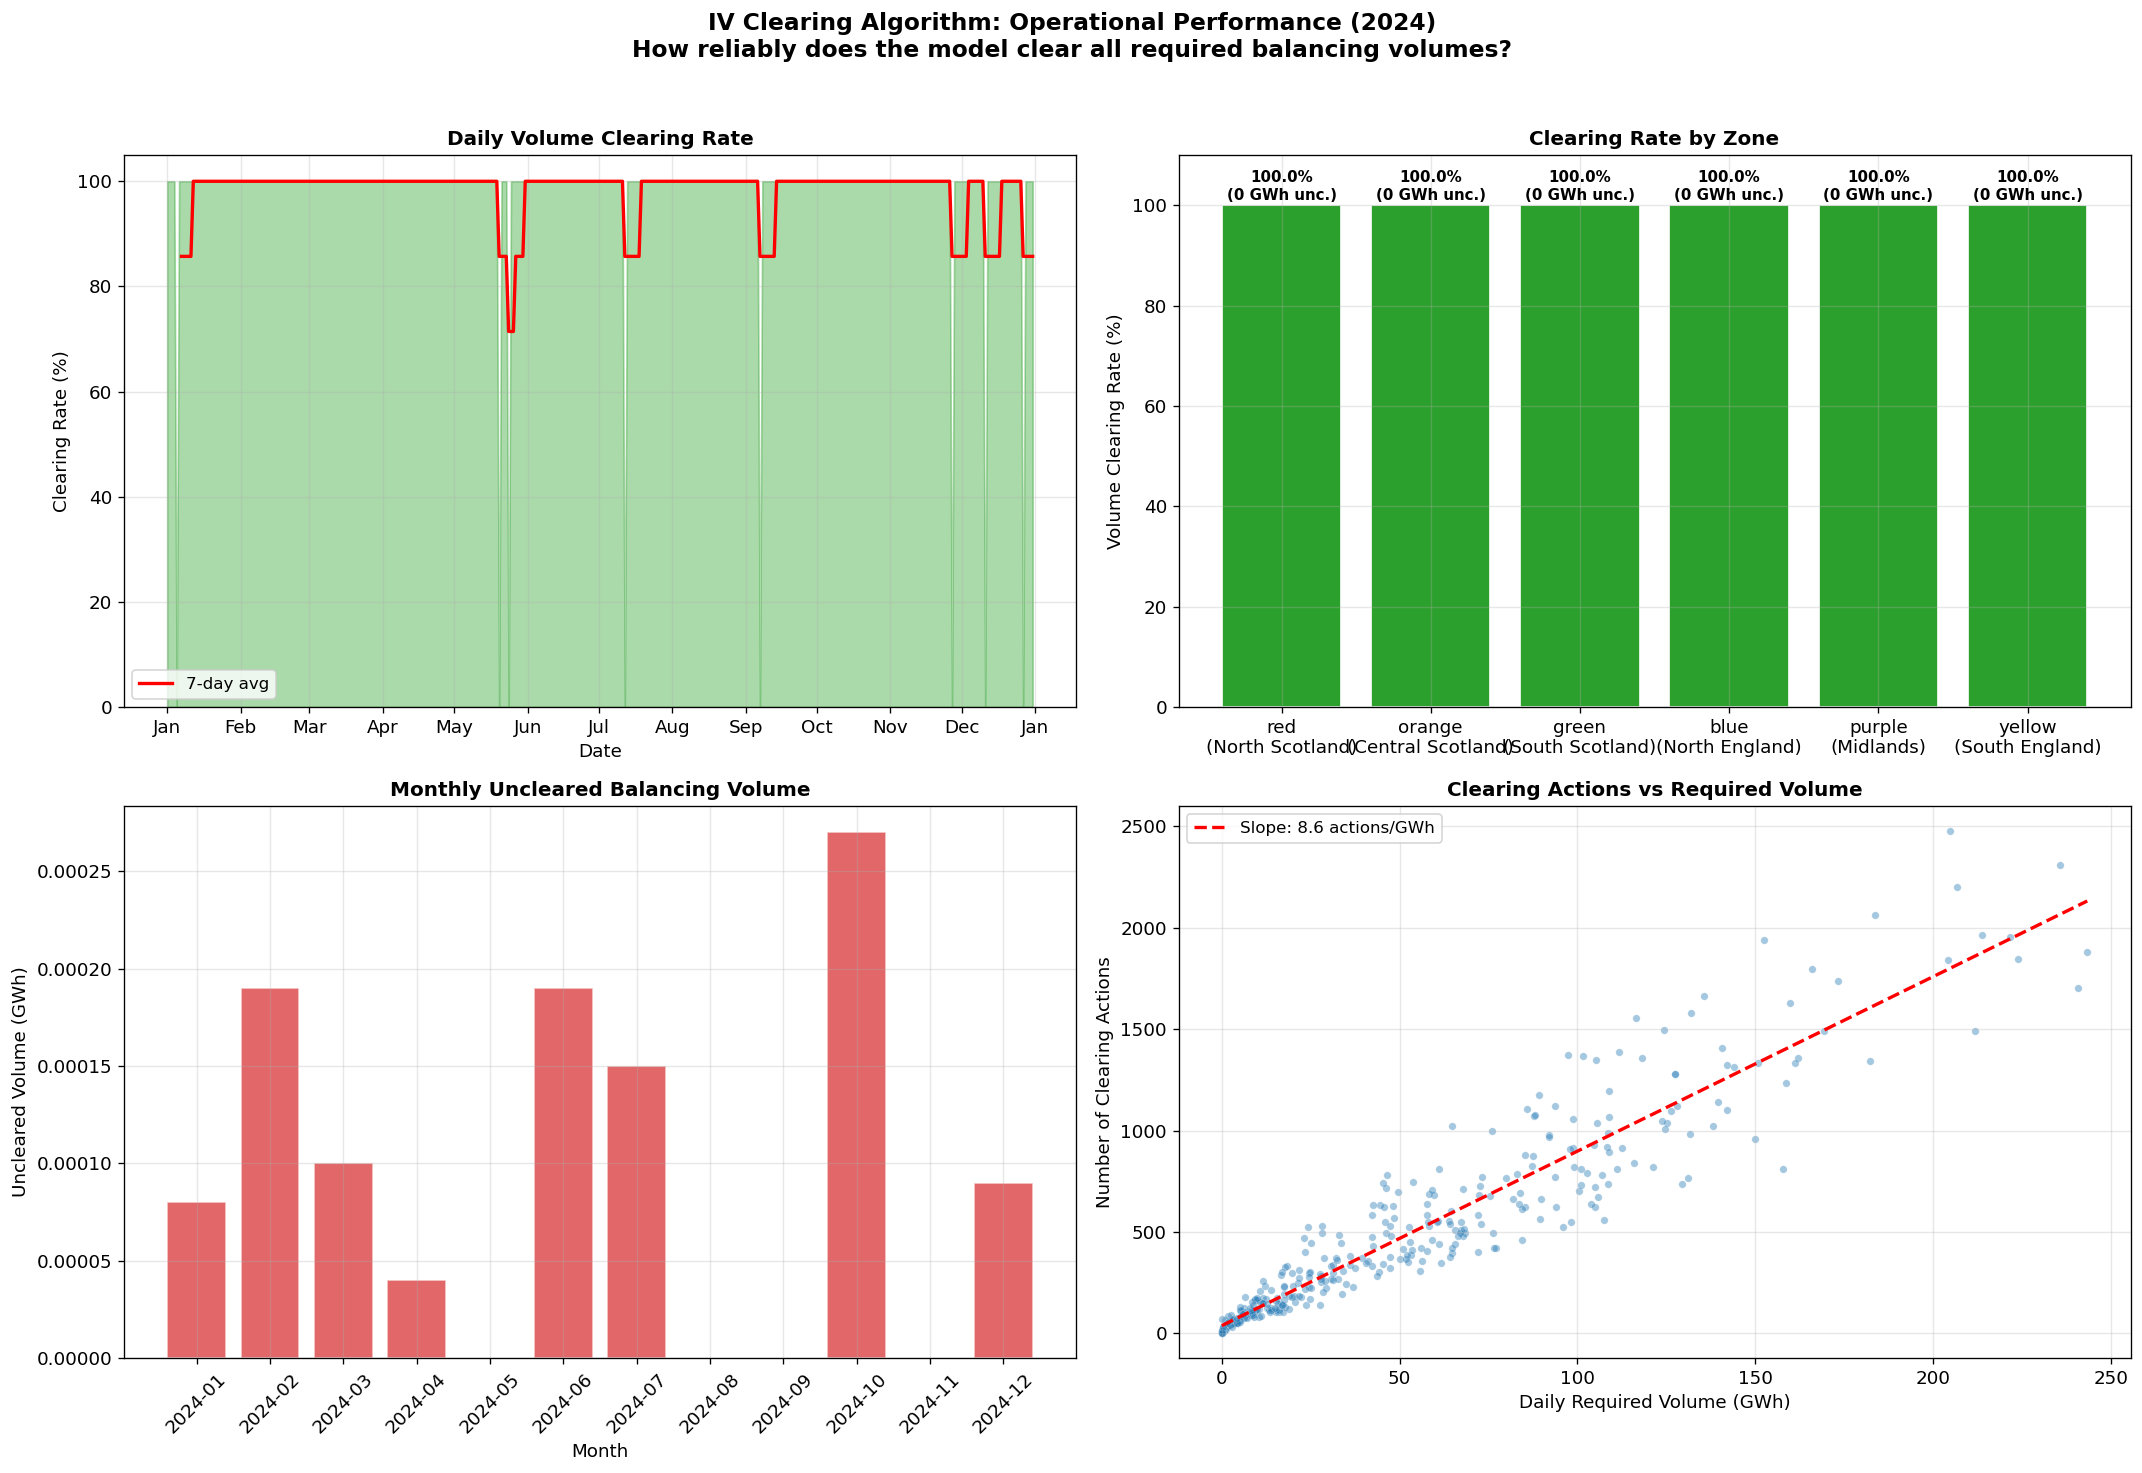


Overall clearing rate: 100.0%
Total required: 19255 GWh
Total cleared: 19255 GWh
Total uncleared: 0 GWh

Days with 100% clearing: 355 / 363


In [ ]:
# "" Plot 7b: Clearing performance """""""""""""""""""""""""""""""""""""""""""""

# Analyse settlement data for clearing performance
settle_clean = settle[settle['zone'].isin(ZONE_ORDER)].copy()
settle_clean['uncleared_flag_bool'] = settle_clean['uncleared_flag'] == 'YES'

# Per-day clearing success rate
daily_settle = settle_clean.groupby('date').agg(
    total_required=('required_volume_mwh', lambda x: x.abs().sum()),
    total_cleared=('cleared_volume_mwh', lambda x: x.abs().sum()),
    total_uncleared=('uncleared_volume_mwh', lambda x: x.abs().sum()),
    n_uncleared_flags=('uncleared_flag_bool', 'sum'),
    n_records=('uncleared_flag_bool', 'count'),
)
daily_settle['clear_rate'] = (daily_settle['total_cleared'] / daily_settle['total_required'].clip(lower=0.001) * 100).clip(0, 100)
daily_settle['flag_rate'] = daily_settle['n_uncleared_flags'] / daily_settle['n_records'] * 100

# Zone-level clearing performance
zone_clearing = settle_clean.groupby('zone').agg(
    total_required=('required_volume_mwh', lambda x: x.abs().sum()),
    total_cleared=('cleared_volume_mwh', lambda x: x.abs().sum()),
    total_uncleared=('uncleared_volume_mwh', lambda x: x.abs().sum()),
    n_uncleared=('uncleared_flag_bool', 'sum'),
    n_total=('uncleared_flag_bool', 'count'),
).reindex(ZONE_ORDER)
zone_clearing['clear_rate_pct'] = (zone_clearing['total_cleared'] / zone_clearing['total_required'].clip(lower=0.001) * 100).clip(0, 100)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Panel 1: Daily clearing rate time series
ax = axes[0, 0]
ax.fill_between(daily_settle.index, daily_settle['clear_rate'], alpha=0.4, color='#2ca02c')
ax.plot(daily_settle.index, daily_settle['clear_rate'].rolling(7).mean(), 'r-', linewidth=2, label='7-day avg')
ax.set_xlabel('Date')
ax.set_ylabel('Clearing Rate (%)')
ax.set_title('Daily Volume Clearing Rate', fontsize=12, fontweight='bold')
ax.set_ylim(0, 105)
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Panel 2: Zone clearing performance
ax = axes[0, 1]
zone_labels = [f"{z}\n({ZONE_NAMES[z]})" for z in ZONE_ORDER]
colors = ['#2ca02c' if r >= 95 else '#ff7f0e' if r >= 80 else '#d62728' for r in zone_clearing['clear_rate_pct']]
bars = ax.bar(zone_labels, zone_clearing['clear_rate_pct'], color=colors, edgecolor='white')
for bar, val, unc in zip(bars, zone_clearing['clear_rate_pct'], zone_clearing['total_uncleared']/1e3):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.1f}%\n({unc:.0f} GWh unc.)', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Volume Clearing Rate (%)')
ax.set_title('Clearing Rate by Zone', fontsize=12, fontweight='bold')
ax.set_ylim(0, 110)

# Panel 3: Monthly uncleared volume
ax = axes[1, 0]
monthly_uncleared = settle_clean.groupby('month')['uncleared_volume_mwh'].sum().abs() / 1e3
months = [str(m) for m in monthly_uncleared.index]
ax.bar(months, monthly_uncleared.values, color='#d62728', alpha=0.7, edgecolor='white')
ax.set_xlabel('Month')
ax.set_ylabel('Uncleared Volume (GWh)')
ax.set_title('Monthly Uncleared Balancing Volume', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)

# Panel 4: Per-day clearing actions vs required volume scatter
ax = axes[1, 1]
daily_vol_required = settle_clean.groupby('date')['required_volume_mwh'].sum().abs() / 1e3
daily_n_actions = iv_actions.groupby('date').size()
common_dates = daily_vol_required.index.intersection(daily_n_actions.index)
ax.scatter(daily_vol_required.loc[common_dates], daily_n_actions.loc[common_dates],
           alpha=0.4, s=20, c='#1f77b4', edgecolors='white', linewidth=0.3)
ax.set_xlabel('Daily Required Volume (GWh)')
ax.set_ylabel('Number of Clearing Actions')
ax.set_title('Clearing Actions vs Required Volume', fontsize=12, fontweight='bold')

# Regression
if len(common_dates) > 10:
    x_r = daily_vol_required.loc[common_dates].values
    y_r = daily_n_actions.loc[common_dates].values
    coeffs = np.polyfit(x_r, y_r, 1)
    x_line = np.linspace(x_r.min(), x_r.max(), 100)
    ax.plot(x_line, np.polyval(coeffs, x_line), 'r--', linewidth=2, label=f'Slope: {coeffs[0]:.1f} actions/GWh')
    ax.legend()

fig.suptitle('IV Clearing Algorithm: Operational Performance (2024)\n'
             'How reliably does the model clear all required balancing volumes?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_clearing_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
overall_clear = zone_clearing['total_cleared'].sum() / zone_clearing['total_required'].sum() * 100
print(f"\nOverall clearing rate: {overall_clear:.1f}%")
print(f"Total required: {zone_clearing['total_required'].sum()/1e3:.0f} GWh")
print(f"Total cleared: {zone_clearing['total_cleared'].sum()/1e3:.0f} GWh")
print(f"Total uncleared: {zone_clearing['total_uncleared'].sum()/1e3:.0f} GWh")
print(f"\nDays with 100% clearing: {(daily_settle['clear_rate'] >= 99.9).sum()} / {len(daily_settle)}")

## Plot 7c: Data Pipeline Overview - File Sizes and Processing Chain

A visual representation of the complete data pipeline: from raw ELEXON API data through network optimisation to final clearing results. Shows file counts and sizes at each stage.

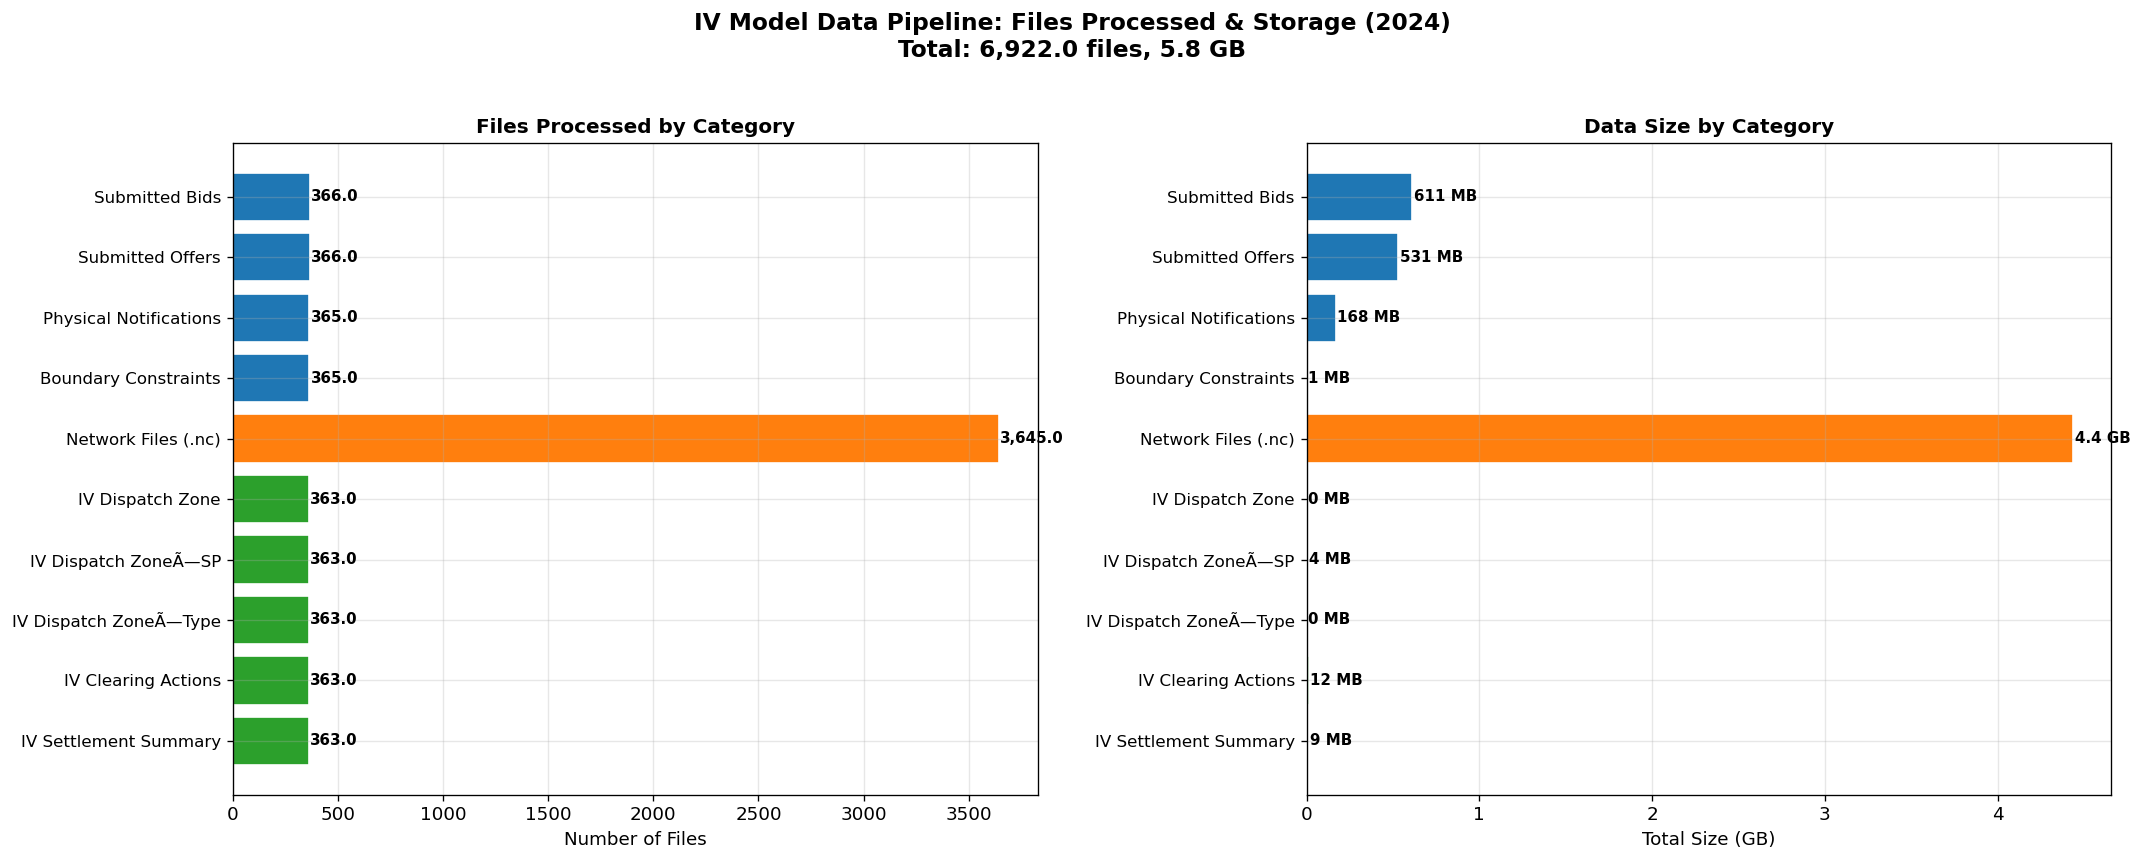


Total files processed: 6,922.0
Total data size: 5.8 GB (5775 MB)


In [ ]:
# "" Plot 7c: Data pipeline file stats """""""""""""""""""""""""""""""""""""""""

import os

# Count and size files by type across all result days
file_categories = {
    'Submitted Bids': ('data/base', 'submitted_bids.csv'),
    'Submitted Offers': ('data/base', 'submitted_offers.csv'),
    'Physical Notifications': ('data/base', 'physical_notifications.csv'),
    'Boundary Constraints': ('data/base', 'boundary_flow_constraints.csv'),
    'Network Files (.nc)': ('results', '*.nc'),
    'IV Dispatch Zone': ('results', 'IV_dispatch_changes_by_zone_flex.csv'),
    'IV Dispatch Zone - SP': ('results', 'IV_dispatch_changes_by_zone_and_SP_flex.csv'),
    'IV Dispatch Zone - Type': ('results', 'IV_dispatch_changes_by_zone_and_type_flex.csv'),
    'IV Clearing Actions': ('results', 'IV_clearing_accepted_actions_flex.csv'),
    'IV Settlement Summary': ('results', 'IV_clearing_settlement_summary_flex.csv'),
}

pipeline_stats = {}
for label, (base_dir, pattern) in file_categories.items():
    total_size = 0
    count = 0
    for day_str in all_dates:
        if pattern == '*.nc':
            day_path = ROOT / base_dir / day_str
            if day_path.exists():
                for f in day_path.glob('*.nc'):
                    total_size += f.stat().st_size
                    count += 1
        else:
            fpath = ROOT / base_dir / day_str / pattern
            if fpath.exists():
                total_size += fpath.stat().st_size
                count += 1
    pipeline_stats[label] = {'count': count, 'size_mb': total_size / 1e6}

stats_df = pd.DataFrame(pipeline_stats).T
stats_df['size_gb'] = stats_df['size_mb'] / 1e3

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# File counts
ax = axes[0]
colors_pipe = ['#1f77b4'] * 4 + ['#ff7f0e'] + ['#2ca02c'] * 5
bars = ax.barh(range(len(stats_df)), stats_df['count'], color=colors_pipe, edgecolor='white')
ax.set_yticks(range(len(stats_df)))
ax.set_yticklabels(stats_df.index, fontsize=10)
ax.set_xlabel('Number of Files')
ax.set_title('Files Processed by Category', fontsize=12, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, stats_df['count']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, fontweight='bold')

# File sizes
ax = axes[1]
bars = ax.barh(range(len(stats_df)), stats_df['size_gb'], color=colors_pipe, edgecolor='white')
ax.set_yticks(range(len(stats_df)))
ax.set_yticklabels(stats_df.index, fontsize=10)
ax.set_xlabel('Total Size (GB)')
ax.set_title('Data Size by Category', fontsize=12, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, stats_df['size_gb']):
    label = f'{val:.1f} GB' if val >= 1 else f'{val*1e3:.0f} MB'
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=9, fontweight='bold')

fig.suptitle('IV Model Data Pipeline: Files Processed & Storage (2024)\n'
             f'Total: {stats_df["count"].sum():,} files, {stats_df["size_gb"].sum():.1f} GB',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_pipeline_stats.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal files processed: {stats_df['count'].sum():,}")
print(f"Total data size: {stats_df['size_gb'].sum():.1f} GB ({stats_df['size_mb'].sum():.0f} MB)")

---
# Summary

This notebook has investigated the flexibility requirements of the GB transmission system as modelled by the IV zonal clearing algorithm across the full year 2024. Key findings:

**Zonal Asymmetry (Section 1):**
- Northern zones (red/orange) are dominated by **flex-down** (curtailment) - excess wind generation that cannot flow south
- Central/southern zones (blue/purple) are dominated by **flex-up** - compensating generation to replace curtailed northern output
- The system approximately balances: total curtailment ~ total ramp-up

**Seasonal Patterns (Section 2):**
- Winter months show significantly higher congestion than summer (driven by wind output)
- The daily time series reveals high day-to-day variability on top of the seasonal trend
- Intraday profiles show when congestion peaks within each day

**Wind-Curtailment Link (Section 4):**
- Strong positive correlation between northern wind output and curtailment volumes
- Winter months cluster at the high end of both wind and curtailment

**Clearing Prices (Section 5):**
- Offer prices vary seasonally with scarcity of flex-up providers
- Different technologies command different prices, revealing the merit order

**Technology Flexibility (Section 6):**
- The flexibility "menu" varies significantly by season and technology
- Some technologies are heavily utilised (high acceptance rate), others have spare capacity

**Data Scale (Section 7):**
- Millions of individual bids and offers processed from the ELEXON API
- Hundreds of network optimisations solved
- Comprehensive clearing performance across all 366 days

## Plot 5b: Monthly Clearing Prices by Technology

Which technologies set the marginal price? This reveals whether gas (expensive flex-up) or wind (negative flex-down via CfD) dominates the clearing price structure at different times of year.